# Промышленность

## Описание проекта

Чтобы оптимизировать производственные расходы, металлургический комбинат «Стальная птица» решил уменьшить потребление электроэнергии на этапе обработки стали.  
Для этого комбинату нужно контролировать температуру сплава.  
Задача — построить модель, которая будет её предсказывать.  
Заказчик хочет использовать разработанную модель для имитации технологического процесса.  

## Описание процесса обработки

Сталь обрабатывают в металлическом ковше вместимостью около 100 тонн.  
Чтобы ковш выдерживал высокие температуры, изнутри его облицовывают огнеупорным кирпичом.  
Расплавленную сталь заливают в ковш и подогревают до нужной температуры графитовыми электродами. Они установлены на крышке ковша.  
Сначала происходит десульфурация — из стали выводят серу и корректируют её химический состав добавлением примесей.  
Затем сталь легируют — добавляют в неё куски сплава из бункера для сыпучих материалов или порошковую проволоку через специальный трайб-аппарат.  
Прежде чем в первый раз ввести легирующие добавки, специалисты производят химический анализ стали и измеряют её температуру.  
Потом температуру на несколько минут повышают, уже после этого добавляют легирующие материалы и продувают сталь инертным газом, чтобы перемешать, а затем снова проводят измерения.  
Такой цикл повторяется до тех пор, пока не будут достигнуты нужный химический состав стали и оптимальная температура плавки.  
Дальше расплавленная сталь отправляется на доводку металла или поступает в машину непрерывной разливки.  
Оттуда готовый продукт выходит в виде заготовок-слябов (англ. slab, «плита»).

## Описание данных

Данные хранятся в Sqlite  — СУБД, в которой база данных представлена одним файлом.  
Она состоит из нескольких таблиц:  
- steel.data_arc — данные об электродах;  
- steel.data_bulk — данные об объёме сыпучих материалов;  
- steel.data_bulk_time — данные о времени подачи сыпучих материалов;  
- steel.data_gas — данные о продувке сплава газом;  
- steel.data_temp — данные об измерениях температуры;  
- steel.data_wire — данные об объёме проволочных материалов;  
- steel.data_wire_time — данные о времени подачи проволочных материалов.  

Таблица steel.data_arc  
- key — номер партии;
- BeginHeat — время начала нагрева;
- EndHeat — время окончания нагрева;
- ActivePower — значение активной мощности;
- ReactivePower — значение реактивной мощности.

Таблица steel.data_bulk
- key — номер партии;
- Bulk1 … Bulk15 — объём подаваемого материала.  

Таблица steel.data_bulk_time  
- key — номер партии;
- Bulk1 … Bulk15 — время подачи материала.

Таблица steel.data_gas
- key — номер партии;
- gas — объём подаваемого газа.

Таблица steel.data_temp
- key — номер партии;
- MesaureTime — время замера;
- Temperature — значение температуры.

Таблица steel.data_wire
- key — номер партии;
- Wire1 … Wire9 — объём подаваемых проволочных материалов.

Таблица steel.data_wire_time
- key — номер партии;
- Wire1 … Wire9 — время подачи проволочных материалов.  

Во всех файлах столбец key содержит номер партии.  
В таблицах может быть несколько строк с одинаковым значением key: они соответствуют разным итерациям обработки.

# Проектирование

## Импорты

In [1]:
import os
import pandas as pd
from sqlalchemy import create_engine, inspect, Table, MetaData
from sqlalchemy.orm import sessionmaker
import logging
import warnings
import seaborn as sns
import numpy as np

import re
import missingno as msno
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

import phik
from phik import phik_matrix

# ============================================
# НАСТРОЙКИ ЛОГИРОВАНИЯ И ПРЕДУПРЕЖДЕНИЙ
# ============================================
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s: %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger(__name__)

# Отключаем лишние предупреждения
warnings.filterwarnings("ignore")

## Константы

In [2]:
BD = '../data/ds-plus-final.db'
RANDOM_STATE = 10326
TEST_SIZE = 0.25
TARGET = 'конечная_температура'

## Функции проекта

In [3]:
# сделаем функцию оценки пропусков в датасетах
def missing_data(data):
    missing_data = data.isna().sum()
    missing_data = missing_data[missing_data > 0]
    display(missing_data)


# функция для обработки пробелов
def process_spaces(s):
    if isinstance(s, str):
        s = s.strip()
        s = " ".join(s.split())
    return s


# замена пробелов на нижнее подчеркинвание в названии столбцов
def replace_spaces(s):
    if isinstance(s, str):
        s = s.strip()
        s = "_".join(s.split())
    return s


def drop_duplicated(data):
    # проверка дубликатов
    logger.info("Проверим дубликаты и удалим, если есть")
    num_duplicates = data.duplicated().sum()
    display(num_duplicates)

    if num_duplicates > 0:
        logger.info("Удаляем")
        data = data.drop_duplicates(keep="first").reset_index(
            drop=True
        )  # обновляем DataFrame
    else:
        logger.info("Дубликаты отсутствуют")
    return data


def normalize_columns(columns):
    new_cols = []
    for col in columns:
        # вставляем "_" перед заглавной буквой (латиница или кириллица), кроме первой
        col = re.sub(r"(?<!^)(?=[A-ZА-ЯЁ])", "_", col)
        # приводим к нижнему регистру
        col = col.lower()
        new_cols.append(col)
    return new_cols


def check_data(data):
    # приведем все к нижнему регистру
    data.columns = normalize_columns(data.columns)

    # удалим лишние пробелы в строках
    for col in data.columns:
        if data[col].dtype == "object":
            data[col] = data[col].apply(
                lambda x: process_spaces(x) if isinstance(x, str) else x
            )

    # и в названии столбцов
    data.columns = [replace_spaces(col) for col in data.columns]

    # строки в ячейках строчными буквами
    for col in data.columns:
        if data[col].dtype == "object":
            # Безопасное преобразование: только для строк, игнорируем None и не-строки
            data[col] = data[col].apply(
                lambda x: x.lower() if isinstance(x, str) else x
            )

    # общая информация
    logger.info("Общая информация базы данных")
    display(data.info())

    # 5 строк
    logger.info("5 случайных строк")
    display(data.sample(5))

    # пропуски
    logger.info("Число пропусков в базе данных")
    display(missing_data(data))

    # проверка на наличие пропусков
    if data.isnull().sum().sum() > 0:
        logger.info("Визуализация пропусков")
        msno.bar(data)
        plt.show()

    # средние характеристики
    logger.info("Характеристики базы данных")
    display(data.describe().T)

    # data = drop_duplicated(data)

    return data  # возвращаем измененные данные

def plot_combined(data, col=None, target=None, col_type=None, legend_loc='best'):
    """
    Строит графики для числовых столбцов в DataFrame, автоматически определяя их типы (дискретные или непрерывные).

    :param data: DataFrame, содержащий данные для визуализации.
    :param col: Список столбцов для построения графиков. Если None, будут использованы все числовые столбцы.
    :param target: Столбец, по которому будет производиться разделение (для hue в графиках).
    :param col_type: Словарь, определяющий типы столбцов ('col' для непрерывных и 'dis' для дискретных).
                     Если None, типы будут определены автоматически.
    :param legend_loc: Положение легенды для графиков (по умолчанию 'best').
    :return: None. Графики отображаются с помощью plt.show().
    """
    
    # Определяем числовые столбцы
    if col is None:
        numerical_columns = data.select_dtypes(include=['int', 'float']).columns.tolist()
    else:
        numerical_columns = col

    # Если col_type не указан, определяем типы автоматически
    if col_type is None:
        col_type = {}
        for col in numerical_columns:
            unique_count = data[col].nunique()
            if unique_count > 20:
                col_type[col] = 'col'  # Непрерывные данные
            else:
                col_type[col] = 'dis'  # Дискретные данные

    total_plots = len(numerical_columns) * 2
    ncols = 2
    nrows = (total_plots + ncols - 1) // ncols

    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 5 * nrows))
    axs = axs.flatten()

    index = 0

    for col in numerical_columns:
        # Определяем тип графика
        plot_type = col_type.get(col)
        if plot_type is None:
            raise ValueError(f"Тип для столбца '{col}' не указан в col_type.")

        # Гистограмма или countplot
        if index < len(axs):
            if plot_type == 'col':
                if target is not None:
                    sns.histplot(data, x=col, hue=target, bins=20, kde=True, ax=axs[index])
                    handles, labels = axs[index].get_legend_handles_labels()
                    if handles:
                        axs[index].legend(title=target, loc=legend_loc)
                else:
                    sns.histplot(data[col].dropna(), bins=20, kde=True, ax=axs[index])
                axs[index].set_title(f'Гистограмма: {col}')
            elif plot_type == 'dis':
                if target is not None:
                    sns.countplot(data=data, x=col, hue=target, ax=axs[index])
                    handles, labels = axs[index].get_legend_handles_labels()
                    if handles:
                        axs[index].legend(title=target, loc=legend_loc)
                else:
                    sns.countplot(data=data, x=col, ax=axs[index])
                axs[index].set_title(f'Countplot: {col}')
            index += 1

        # Боксплот
        if index < len(axs):
            sns.boxplot(x=data[col], ax=axs[index])
            axs[index].set_title(f'Боксплот: {col}')
            index += 1

    # Отключаем оставшиеся оси
    for j in range(index, len(axs)):
        axs[j].axis('off')

    plt.tight_layout()
    plt.show()

## Загрузка данных

### Подключение движка

In [4]:
metadata = MetaData()
engine = create_engine(f'sqlite:///{BD}', echo=False)
inspector = inspect(engine)
Session = sessionmaker(engine)

### Исследовательский анализ

#### Данные в БД

In [5]:
# посмотрим что есть в БД
table_names = inspector.get_table_names()
logger.info(table_names)

2026-03-03 22:09:53 [INFO] __main__: ['contract', 'data_arc', 'data_bulk', 'data_bulk_time', 'data_gas', 'data_temp', 'data_wire', 'data_wire_time', 'internet', 'personal', 'phone']


В нашем файлике есть еще и "левые данные" по второму проекту  
Ну да пусть будут, нам нужны только с префикмом data_ 


#### Наличие данных в таблицах

In [6]:
# объявим переменные
data_arc = Table('data_arc', metadata, autoload_with=engine)
data_bulk = Table('data_bulk', metadata, autoload_with=engine)
data_bulk_time = Table('data_bulk_time', metadata, autoload_with=engine)
data_gas = Table('data_gas', metadata, autoload_with=engine)
data_temp = Table('data_temp', metadata, autoload_with=engine)
data_wire = Table('data_wire', metadata, autoload_with=engine)
data_wire_time = Table('data_wire_time', metadata, autoload_with=engine)

In [7]:
# и преобразуем в пандас для удобства работы
df_arc = pd.read_sql(data_arc.select(), engine)
df_bulk = pd.read_sql(data_bulk.select(), engine)
df_bulk_time = pd.read_sql(data_bulk_time.select(), engine)
df_gas = pd.read_sql(data_gas.select(), engine)
df_temp = pd.read_sql(data_temp.select(), engine)
df_wire = pd.read_sql(data_wire.select(), engine)
df_wire_time = pd.read_sql(data_wire_time.select(), engine)

##### df_arc

1. Изучить пропуски и аномалии, распределение признаков;  
2. Скорректировать или удалить партии с аномальными значениями;  
3. Генерация новых признаков - длительность нагрева, общую мощность, соотношение активной мощности к реактивной, количество запуска нагрева электродами;  

In [8]:
df_arc = check_data(df_arc)

2026-03-03 22:09:54 [INFO] __main__: Общая информация базы данных


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   key                   14876 non-null  int64  
 1   начало_нагрева_дугой  14876 non-null  object 
 2   конец_нагрева_дугой   14876 non-null  object 
 3   активная_мощность     14876 non-null  float64
 4   реактивная_мощность   14876 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 581.2+ KB


None

2026-03-03 22:09:54 [INFO] __main__: 5 случайных строк


,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность
1983,427,2019-05-19 19:39:25,2019-05-19 19:41:40,0.482525,0.323222
9925,2150,2019-07-29 06:11:07,2019-07-29 06:12:43,0.964680,0.749540
6227,1355,2019-06-23 16:41:30,2019-06-23 16:43:25,0.661383,0.581167
8323,1811,2019-07-09 18:13:16,2019-07-09 18:16:21,0.428844,0.306111
1658,357,2019-05-17 08:54:56,2019-05-17 08:59:47,0.403314,0.250155


2026-03-03 22:09:54 [INFO] __main__: Число пропусков в базе данных


Series([], dtype: int64)

None

2026-03-03 22:09:54 [INFO] __main__: Характеристики базы данных


,count,mean,std,min,25%,50%,75%,max
key,14876.0,1615.220422,934.571502,1.000000,806.000000,1617.000000,2429.000000,3241.000000
активная_мощность,14876.0,0.662752,0.258885,0.223120,0.467115,0.599587,0.830070,1.463773
реактивная_мощность,14876.0,0.438986,5.873485,-715.479924,0.337175,0.441639,0.608201,1.270284


Пропусков нет  
Даты надо преобразовать в нормальный тип  

Что проверить  
1) сопоставление дат - начало должно быть раньше конца  

In [9]:
df_arc['начало_нагрева_дугой'] = df_arc['начало_нагрева_дугой'].astype('datetime64[ns]')
df_arc['конец_нагрева_дугой'] = df_arc['конец_нагрева_дугой'].astype('datetime64[ns]')

In [10]:
df_arc['продолжительность_нагрева_сек'] = (df_arc['конец_нагрева_дугой'] - df_arc['начало_нагрева_дугой']).dt.total_seconds()

In [11]:
df_arc.describe().T

,count,mean,min,25%,50%,75%,max,std
key,14876.0,1615.220422,1.0,806.0,1617.0,2429.0,3241.0,934.571502
начало_нагрева_дугой,14876,2019-07-05 12:25:51.921081088,2019-05-03 11:02:14,2019-06-03 23:18:23.249999872,2019-07-03 01:31:26.500000,2019-08-07 22:52:20.750000128,2019-09-06 17:24:54,NaN
конец_нагрева_дугой,14876,2019-07-05 12:28:43.592027392,2019-05-03 11:06:02,2019-06-03 23:21:35,2019-07-03 01:35:13,2019-08-07 22:56:47,2019-09-06 17:26:15,NaN
активная_мощность,14876.0,0.662752,0.22312,0.467115,0.599587,0.83007,1.463773,0.258885
реактивная_мощность,14876.0,0.438986,-715.479924,0.337175,0.441639,0.608201,1.270284,5.873485
продолжительность_нагрева_сек,14876.0,171.670946,11.0,107.0,147.0,214.0,907.0,98.186803


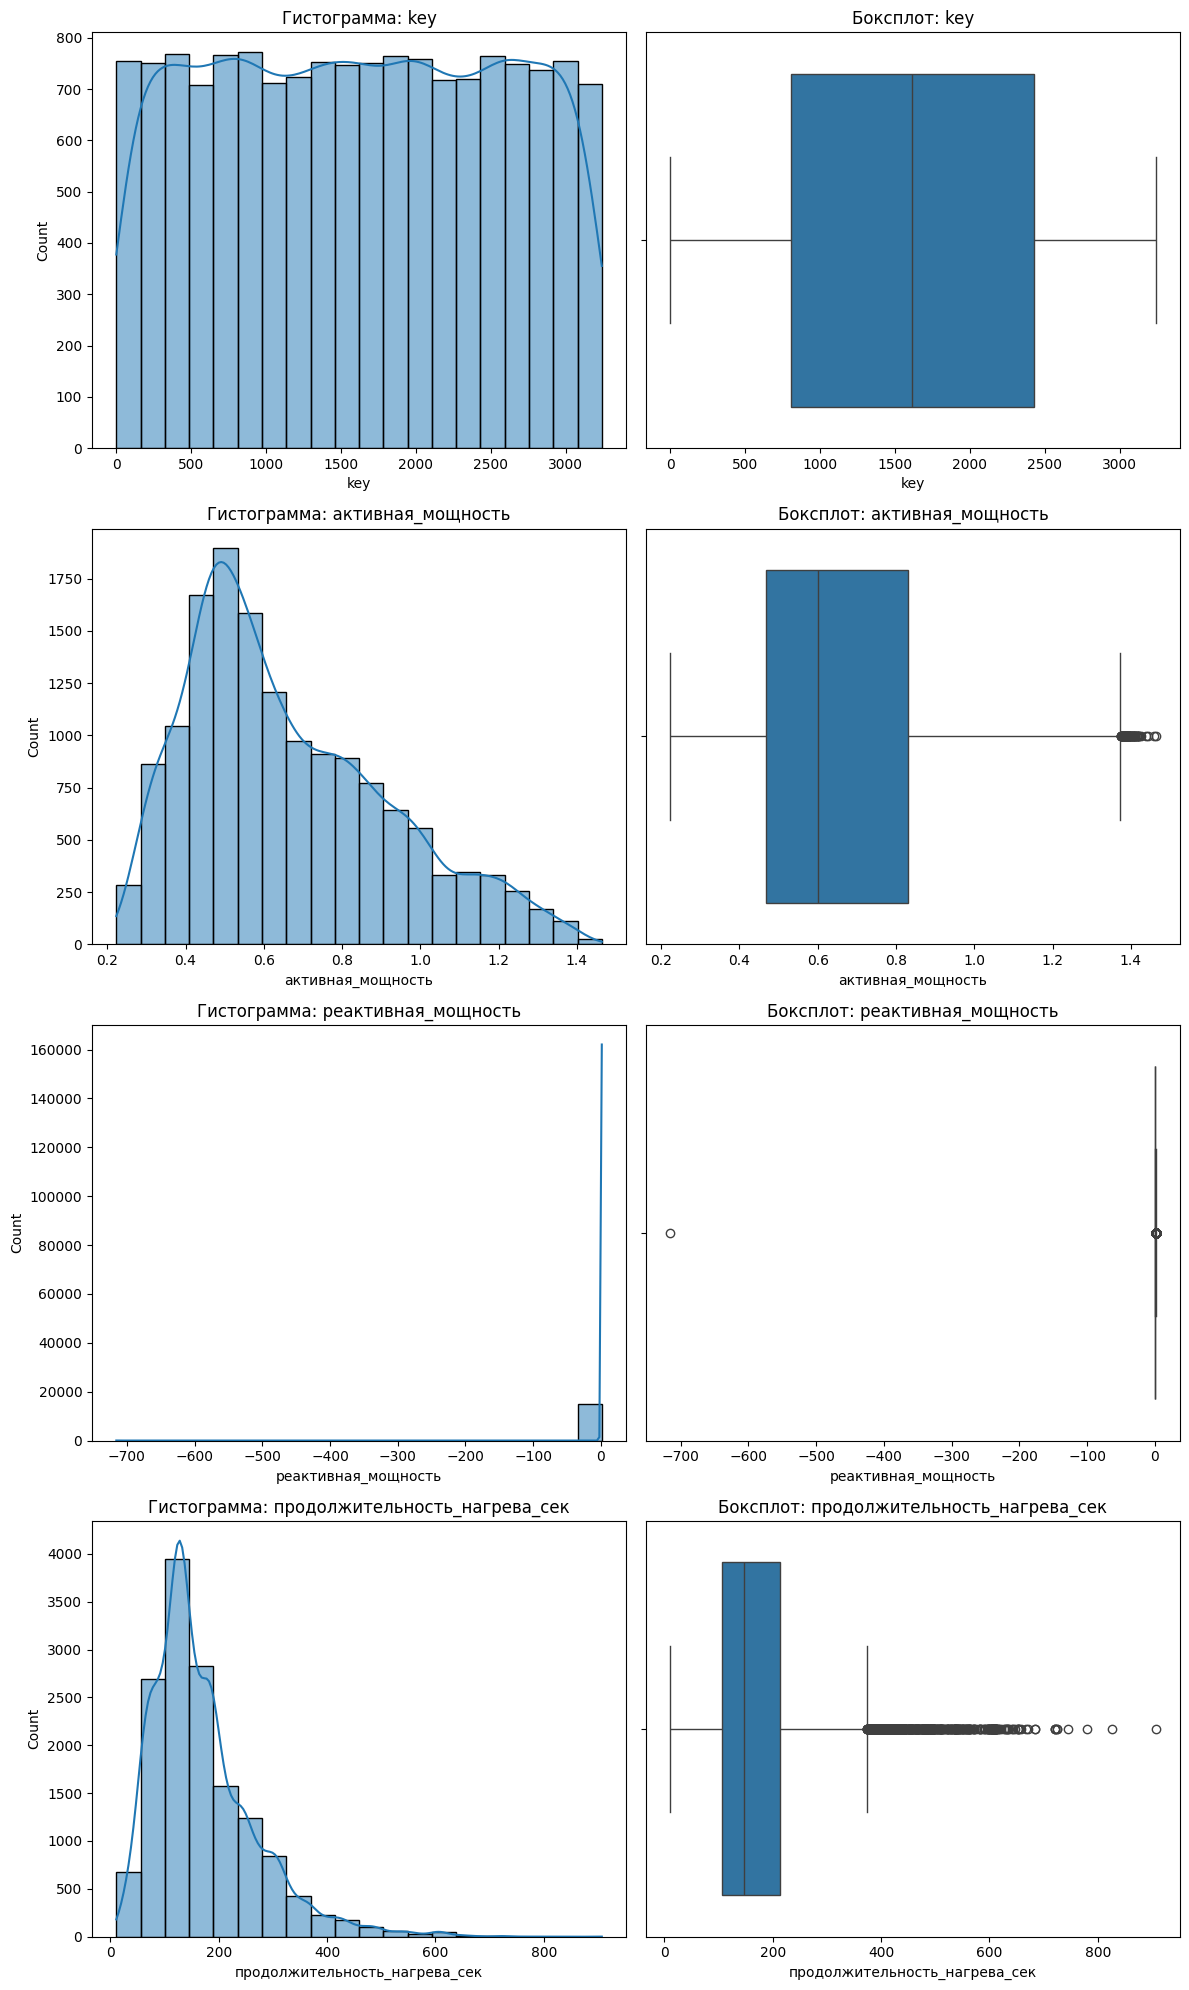

In [12]:
# теперь посмотрим распределение данных
plot_combined(df_arc, col=None, target=None, col_type=None, legend_loc='best')

Везде наблюдаем наличие сильных выбросов, проверим детальнее

In [13]:
df_arc[df_arc['активная_мощность'] > 1.3]

,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность,продолжительность_нагрева_сек
171,38,2019-05-04 17:18:40,2019-05-04 17:21:07,1.336674,1.213404,147.0
296,64,2019-05-05 22:47:19,2019-05-05 22:49:19,1.316444,1.054070,120.0
331,70,2019-05-06 04:00:31,2019-05-06 04:02:06,1.341706,0.950409,95.0
493,106,2019-05-07 08:16:16,2019-05-07 08:21:28,1.327936,0.969106,312.0
517,113,2019-05-07 15:41:34,2019-05-07 15:43:52,1.317665,0.945464,138.0
...,...,...,...,...,...,...
14368,3123,2019-09-02 16:59:39,2019-09-02 17:00:40,1.330737,0.915607,61.0
14549,3166,2019-09-03 22:18:01,2019-09-03 22:20:04,1.368719,1.083031,123.0
14577,3172,2019-09-04 05:58:03,2019-09-04 06:03:15,1.316411,0.886694,312.0
14775,3219,2019-09-05 21:47:29,2019-09-05 21:51:18,1.347920,1.025508,229.0


Значения увеличиваются равномерно и постепенно, сложно сказать ошибка это или нет

In [14]:
df_arc[df_arc['реактивная_мощность'] < 0]

,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность,продолжительность_нагрева_сек
9780,2116,2019-07-28 02:22:08,2019-07-28 02:23:57,0.705344,-715.479924,109.0


Явная ошибка заполнения данных, посчитаем среднюю активная_мощность и среднюю реактивная_мощность  
Посмотрим коэффицент изменения и изменим эту ошибку соответственно

In [15]:
avg_act_power = df_arc['активная_мощность'].mean()
avg_react_power = df_arc['реактивная_мощность'].mean()
koef_power = (avg_act_power / avg_react_power) - 1
logger.info(avg_act_power)
logger.info(avg_react_power)
logger.info(koef_power)


2026-03-03 22:09:55 [INFO] __main__: 0.6627522122882497
2026-03-03 22:09:55 [INFO] __main__: 0.43898642672761495
2026-03-03 22:09:55 [INFO] __main__: 0.5097328116239874


In [16]:
df_arc.loc[df_arc['реактивная_мощность'] < 0, 'реактивная_мощность'] = df_arc['активная_мощность'] * koef_power

In [17]:
df_arc[df_arc['продолжительность_нагрева_сек'] > 400]

,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность,продолжительность_нагрева_сек
20,5,2019-05-03 13:23:32,2019-05-03 13:30:27,0.461620,0.308665,415.0
30,8,2019-05-03 14:53:56,2019-05-03 15:01:11,0.401980,0.292894,435.0
94,21,2019-05-04 03:42:26,2019-05-04 03:52:24,0.639156,0.425871,598.0
137,30,2019-05-04 10:49:25,2019-05-04 10:56:44,0.782927,0.546200,439.0
145,32,2019-05-04 12:58:33,2019-05-04 13:07:22,0.502953,0.352604,529.0
...,...,...,...,...,...,...
14654,3188,2019-09-04 20:54:34,2019-09-04 21:01:49,0.315474,0.254738,435.0
14659,3189,2019-09-04 22:29:02,2019-09-04 22:35:47,1.012875,0.772938,405.0
14772,3218,2019-09-05 20:49:26,2019-09-05 20:57:17,1.281652,1.074167,471.0
14779,3220,2019-09-05 22:35:56,2019-09-05 22:43:26,0.994169,0.720291,450.0


Здесь как будто бы тоже всё ок по времени, надо детальнее изучать вопрос относительно нормальности плавки

In [18]:
# добавим немного новых фич
df_arc['полная_мощность'] = np.sqrt(df_arc['активная_мощность']**2 + df_arc['реактивная_мощность']**2)
df_arc['соотношение_мощностей'] = df_arc['реактивная_мощность'] / df_arc['активная_мощность']
df_arc['cos_phi'] = 1 / np.sqrt(1 + df_arc['соотношение_мощностей']**2)

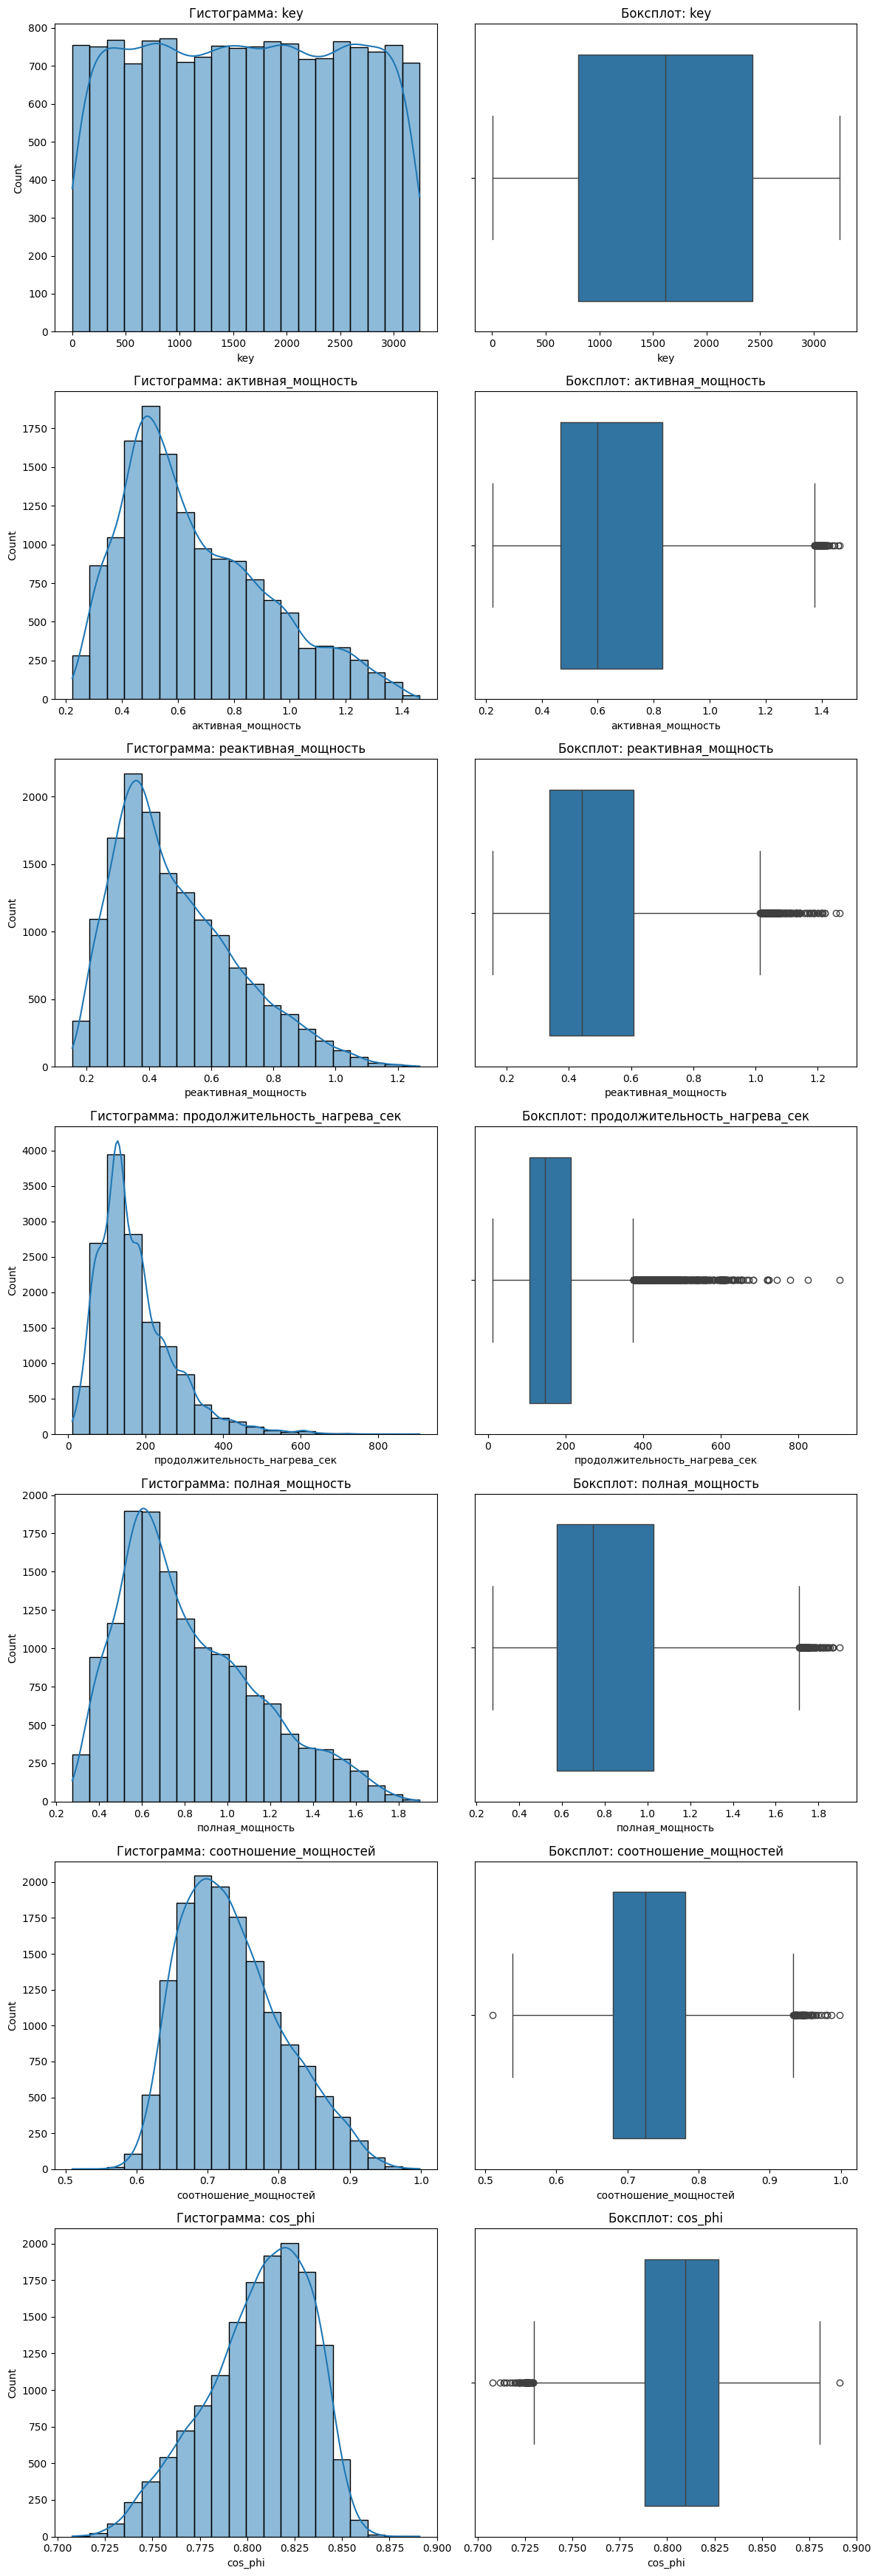

In [19]:
# теперь посмотрим распределение данных
plot_combined(df_arc, col=None, target=None, col_type=None, legend_loc='best')

In [20]:
display(df_arc.info())
display(df_arc.head())
display(df_arc.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   key                            14876 non-null  int64         
 1   начало_нагрева_дугой           14876 non-null  datetime64[ns]
 2   конец_нагрева_дугой            14876 non-null  datetime64[ns]
 3   активная_мощность              14876 non-null  float64       
 4   реактивная_мощность            14876 non-null  float64       
 5   продолжительность_нагрева_сек  14876 non-null  float64       
 6   полная_мощность                14876 non-null  float64       
 7   соотношение_мощностей          14876 non-null  float64       
 8   cos_phi                        14876 non-null  float64       
dtypes: datetime64[ns](2), float64(6), int64(1)
memory usage: 1.0 MB


None

,key,начало_нагрева_дугой,конец_нагрева_дугой,активная_мощность,реактивная_мощность,продолжительность_нагрева_сек,полная_мощность,соотношение_мощностей,cos_phi
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253,228.0,0.371123,0.692338,0.822181
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438,185.0,0.902319,0.623566,0.848545
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460,172.0,0.722536,0.741772,0.803161
3,1,2019-05-03 11:18:14,2019-05-03 11:24:19,0.518496,0.379979,365.0,0.642824,0.732848,0.806591
4,1,2019-05-03 11:26:09,2019-05-03 11:28:37,0.867133,0.643691,148.0,1.079934,0.742321,0.802950


,count,mean,min,25%,50%,75%,max,std
key,14876.0,1615.220422,1.0,806.0,1617.0,2429.0,3241.0,934.571502
начало_нагрева_дугой,14876,2019-07-05 12:25:51.921081088,2019-05-03 11:02:14,2019-06-03 23:18:23.249999872,2019-07-03 01:31:26.500000,2019-08-07 22:52:20.750000128,2019-09-06 17:24:54,NaN
конец_нагрева_дугой,14876,2019-07-05 12:28:43.592027392,2019-05-03 11:06:02,2019-06-03 23:21:35,2019-07-03 01:35:13,2019-08-07 22:56:47,2019-09-06 17:26:15,NaN
активная_мощность,14876.0,0.662752,0.22312,0.467115,0.599587,0.83007,1.463773,0.258885
реактивная_мощность,14876.0,0.487107,0.153777,0.337192,0.441639,0.608201,1.270284,0.197609
продолжительность_нагрева_сек,14876.0,171.670946,11.0,107.0,147.0,214.0,907.0,98.186803
полная_мощность,14876.0,0.823382,0.275718,0.578847,0.746591,1.03039,1.898158,0.323459
соотношение_мощностей,14876.0,0.734908,0.509733,0.679707,0.724754,0.781162,0.998261,0.072438
cos_phi,14876.0,0.805893,0.707722,0.788058,0.809705,0.827039,0.890932,0.027664


Самое главное, надо переделать ключи в одну строку - в широкий формат

In [21]:
df_arc['число_нагревов'] = df_arc.groupby('key').cumcount() + 1

# Создаем широкий формат с помощью pivot
df_pivot = df_arc.pivot(index='key', columns='число_нагревов', 
                        values=['начало_нагрева_дугой', 'конец_нагрева_дугой', 
                                'активная_мощность', 'реактивная_мощность'])

# Переименовываем колонки
df_pivot.columns = [f'{col[0]}_{col[1]}' for col in df_pivot.columns]
df_pivot = df_pivot.reset_index()

# Добавляем средние значения
df_pivot['средняя_активная_мощность'] = df_arc.groupby('key')['активная_мощность'].mean().values
df_pivot['средняя_реактивная_мощность'] = df_arc.groupby('key')['реактивная_мощность'].mean().values

# Считаем длительность каждого нагрева и среднюю
df_arc['длительность'] = (
    pd.to_datetime(df_arc['конец_нагрева_дугой']) - 
    pd.to_datetime(df_arc['начало_нагрева_дугой'])
).dt.total_seconds()

df_pivot['среднее_время_нагрева_сек'] = df_arc.groupby('key')['длительность'].mean().values
df_arc = df_pivot

In [22]:
logger.info("Одна плавка - одна строчка:")
display(df_arc.head())

2026-03-03 22:09:57 [INFO] __main__: Одна плавка - одна строчка:


,key,начало_нагрева_дугой_1,начало_нагрева_дугой_2,начало_нагрева_дугой_3,начало_нагрева_дугой_4,начало_нагрева_дугой_5,начало_нагрева_дугой_6,начало_нагрева_дугой_7,начало_нагрева_дугой_8,начало_нагрева_дугой_9,...,реактивная_мощность_10,реактивная_мощность_11,реактивная_мощность_12,реактивная_мощность_13,реактивная_мощность_14,реактивная_мощность_15,реактивная_мощность_16,средняя_активная_мощность,средняя_реактивная_мощность,среднее_время_нагрева_сек
0,1,2019-05-03 11:02:14,2019-05-03 11:07:28,2019-05-03 11:11:44,2019-05-03 11:18:14,2019-05-03 11:26:09,NaT,NaT,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.607346,0.428564,219.60
1,2,2019-05-03 11:34:14,2019-05-03 11:38:50,2019-05-03 11:46:19,2019-05-03 11:49:48,NaT,NaT,NaT,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.534852,0.363339,202.75
2,3,2019-05-03 12:06:54,2019-05-03 12:13:52,2019-05-03 12:18:56,2019-05-03 12:25:43,2019-05-03 12:31:14,NaT,NaT,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.812728,0.587491,131.00
3,4,2019-05-03 12:39:37,2019-05-03 12:44:47,2019-05-03 12:48:14,2019-05-03 12:53:12,NaT,NaT,NaT,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.676622,0.514248,185.25
4,5,2019-05-03 13:11:13,2019-05-03 13:18:21,2019-05-03 13:23:32,2019-05-03 13:32:44,NaT,NaT,NaT,NaT,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.563238,0.421998,217.25


In [23]:
# и сразу заменим на 0 пропуски в активной и реактивной мощностях

power_cols = [col for col in df_arc.columns 
              if 'активная_мощность' in col or 'реактивная_мощность' in col]

missing_before = df_arc[power_cols].isna().sum().sum()
df_arc[power_cols] = df_arc[power_cols].fillna(0)

##### df_bulk

2026-03-03 22:09:57 [INFO] __main__: Общая информация базы данных


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   bulk_1   252 non-null    float64
 2   bulk_2   22 non-null     float64
 3   bulk_3   1298 non-null   float64
 4   bulk_4   1014 non-null   float64
 5   bulk_5   77 non-null     object 
 6   bulk_6   576 non-null    object 
 7   bulk_7   25 non-null     object 
 8   bulk_8   1 non-null      object 
 9   bulk_9   19 non-null     object 
 10  bulk_10  176 non-null    object 
 11  bulk_11  177 non-null    object 
 12  bulk_12  2450 non-null   object 
 13  bulk_13  18 non-null     object 
 14  bulk_14  2806 non-null   object 
 15  bulk_15  2248 non-null   object 
dtypes: float64(4), int64(1), object(11)
memory usage: 391.3+ KB


None

2026-03-03 22:09:57 [INFO] __main__: 5 случайных строк


,key,bulk_1,bulk_2,bulk_3,bulk_4,bulk_5,bulk_6,bulk_7,bulk_8,bulk_9,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15
2538,2636,NaN,NaN,84.0,NaN,None,142.0,None,None,None,None,None,None,None,200.0,106.0
555,584,NaN,NaN,NaN,80.0,None,None,None,None,None,None,None,411.0,None,260.0,202.0
336,361,10.0,NaN,NaN,105.0,None,None,None,None,None,None,None,177.0,None,165.0,204.0
1724,1785,NaN,NaN,NaN,NaN,None,None,None,None,None,None,None,None,None,99.0,None
2078,2150,NaN,NaN,25.0,NaN,None,51.0,None,None,None,None,None,330.0,None,200.0,170.0


2026-03-03 22:09:57 [INFO] __main__: Число пропусков в базе данных


bulk_1     2877
bulk_2     3107
bulk_3     1831
bulk_4     2115
bulk_5     3052
bulk_6     2553
bulk_7     3104
bulk_8     3128
bulk_9     3110
bulk_10    2953
bulk_11    2952
bulk_12     679
bulk_13    3111
bulk_14     323
bulk_15     881
dtype: int64

None

2026-03-03 22:09:57 [INFO] __main__: Визуализация пропусков


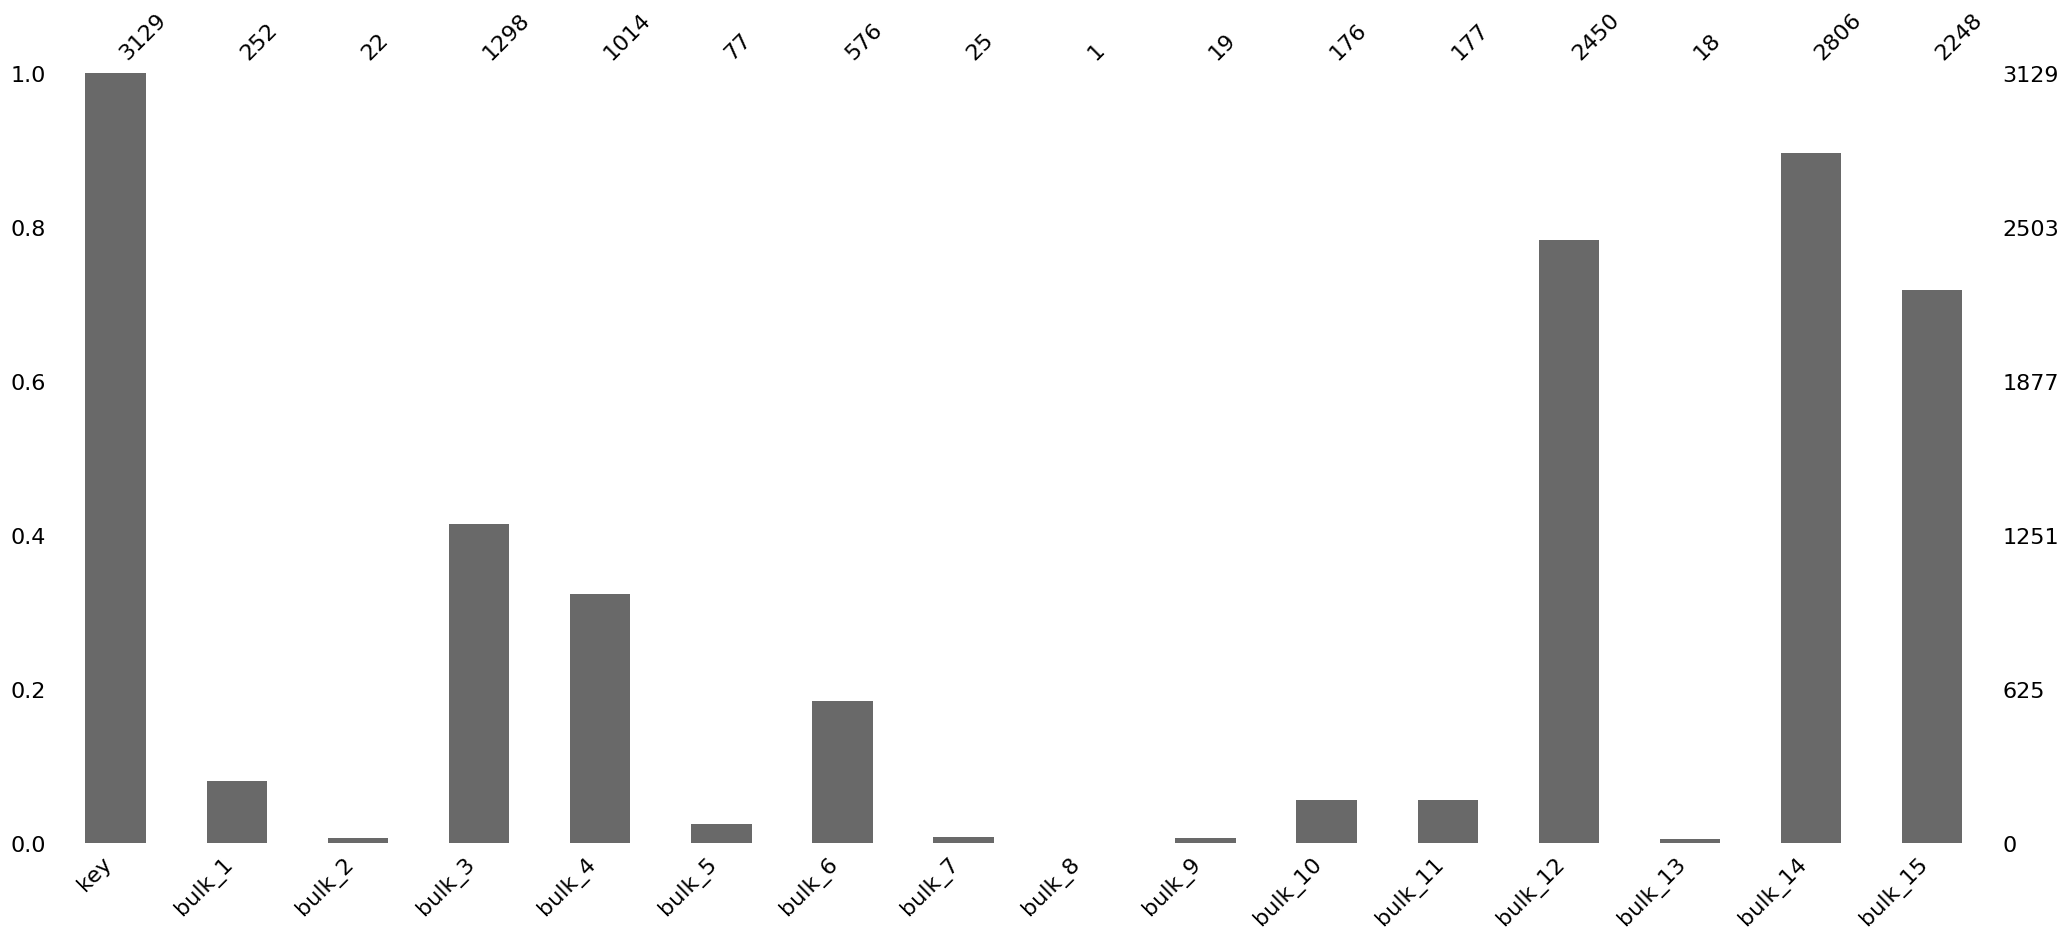

2026-03-03 22:09:57 [INFO] __main__: Характеристики базы данных


,count,mean,std,min,25%,50%,75%,max
key,3129.0,1624.383509,933.337642,1.0,816.0,1622.0,2431.00,3241.0
bulk_1,252.0,39.242063,18.277654,10.0,27.0,31.0,46.00,185.0
bulk_2,22.0,253.045455,21.180578,228.0,242.0,251.5,257.75,325.0
bulk_3,1298.0,113.879045,75.483494,6.0,58.0,97.5,152.00,454.0
bulk_4,1014.0,104.394477,48.184126,12.0,72.0,102.0,133.00,281.0


In [24]:
df_bulk = check_data(df_bulk)

Много пропусков - но это мелочи.  
Заменим на 0, т.к. это просто означает, что не было подачи сыпучего материала.  
Ну и тип данных везде поменять на float  

In [25]:
for col in df_bulk.columns:
    if col != 'key':
        df_bulk[col] = df_bulk[col].astype(float)

In [26]:
df_bulk.describe().T

,count,mean,std,min,25%,50%,75%,max
key,3129.0,1624.383509,933.337642,1.0,816.00,1622.0,2431.00,3241.0
bulk_1,252.0,39.242063,18.277654,10.0,27.00,31.0,46.00,185.0
bulk_2,22.0,253.045455,21.180578,228.0,242.00,251.5,257.75,325.0
bulk_3,1298.0,113.879045,75.483494,6.0,58.00,97.5,152.00,454.0
bulk_4,1014.0,104.394477,48.184126,12.0,72.00,102.0,133.00,281.0
bulk_5,77.0,107.025974,81.790646,11.0,70.00,86.0,132.00,603.0
bulk_6,576.0,118.925347,72.057776,17.0,69.75,100.0,157.00,503.0
bulk_7,25.0,305.600000,191.022904,47.0,155.00,298.0,406.00,772.0
bulk_8,1.0,49.000000,NaN,49.0,49.00,49.0,49.00,49.0
bulk_9,19.0,76.315789,21.720581,63.0,66.00,68.0,70.50,147.0


2026-03-03 22:09:58 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-03 22:09:58 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-03 22:09:58 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-03 22:09:58 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-03 22:09:58 [INFO] matplotlib.category: 

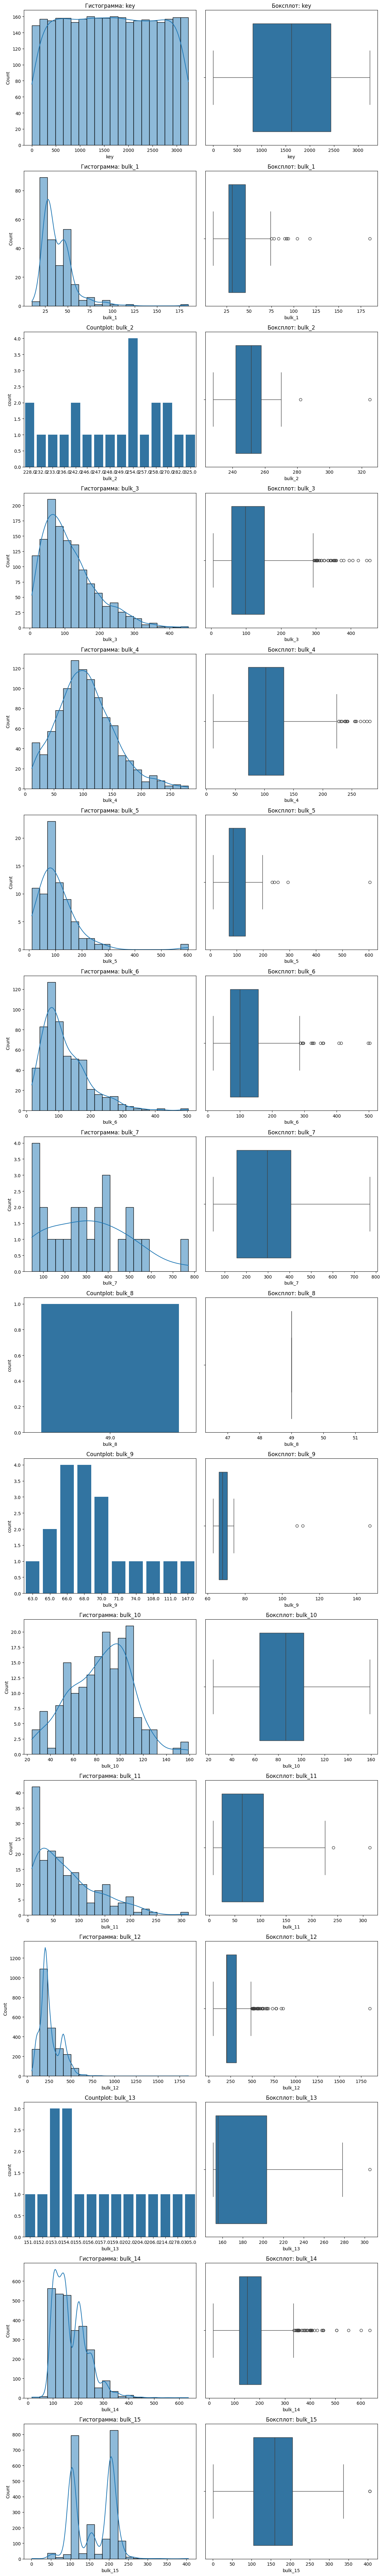

In [27]:
# теперь посмотрим распределение данных
plot_combined(df_bulk, col=None, target=None, col_type=None, legend_loc='best')

Все добавки выше нуля - это главное  
а по числу добавок - сложно понять, что мы добавляем и сколько этого надо...

In [28]:
display(df_bulk.info())
display(df_bulk.head())
display(df_bulk.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   bulk_1   252 non-null    float64
 2   bulk_2   22 non-null     float64
 3   bulk_3   1298 non-null   float64
 4   bulk_4   1014 non-null   float64
 5   bulk_5   77 non-null     float64
 6   bulk_6   576 non-null    float64
 7   bulk_7   25 non-null     float64
 8   bulk_8   1 non-null      float64
 9   bulk_9   19 non-null     float64
 10  bulk_10  176 non-null    float64
 11  bulk_11  177 non-null    float64
 12  bulk_12  2450 non-null   float64
 13  bulk_13  18 non-null     float64
 14  bulk_14  2806 non-null   float64
 15  bulk_15  2248 non-null   float64
dtypes: float64(15), int64(1)
memory usage: 391.3 KB


None

,key,bulk_1,bulk_2,bulk_3,bulk_4,bulk_5,bulk_6,bulk_7,bulk_8,bulk_9,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15
0,1,NaN,NaN,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,150.0,154.0
1,2,NaN,NaN,NaN,73.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,149.0,154.0
2,3,NaN,NaN,NaN,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.0,NaN,152.0,153.0
3,4,NaN,NaN,NaN,81.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,207.0,NaN,153.0,154.0
4,5,NaN,NaN,NaN,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203.0,NaN,151.0,152.0


,count,mean,std,min,25%,50%,75%,max
key,3129.0,1624.383509,933.337642,1.0,816.00,1622.0,2431.00,3241.0
bulk_1,252.0,39.242063,18.277654,10.0,27.00,31.0,46.00,185.0
bulk_2,22.0,253.045455,21.180578,228.0,242.00,251.5,257.75,325.0
bulk_3,1298.0,113.879045,75.483494,6.0,58.00,97.5,152.00,454.0
bulk_4,1014.0,104.394477,48.184126,12.0,72.00,102.0,133.00,281.0
bulk_5,77.0,107.025974,81.790646,11.0,70.00,86.0,132.00,603.0
bulk_6,576.0,118.925347,72.057776,17.0,69.75,100.0,157.00,503.0
bulk_7,25.0,305.600000,191.022904,47.0,155.00,298.0,406.00,772.0
bulk_8,1.0,49.000000,NaN,49.0,49.00,49.0,49.00,49.0
bulk_9,19.0,76.315789,21.720581,63.0,66.00,68.0,70.50,147.0


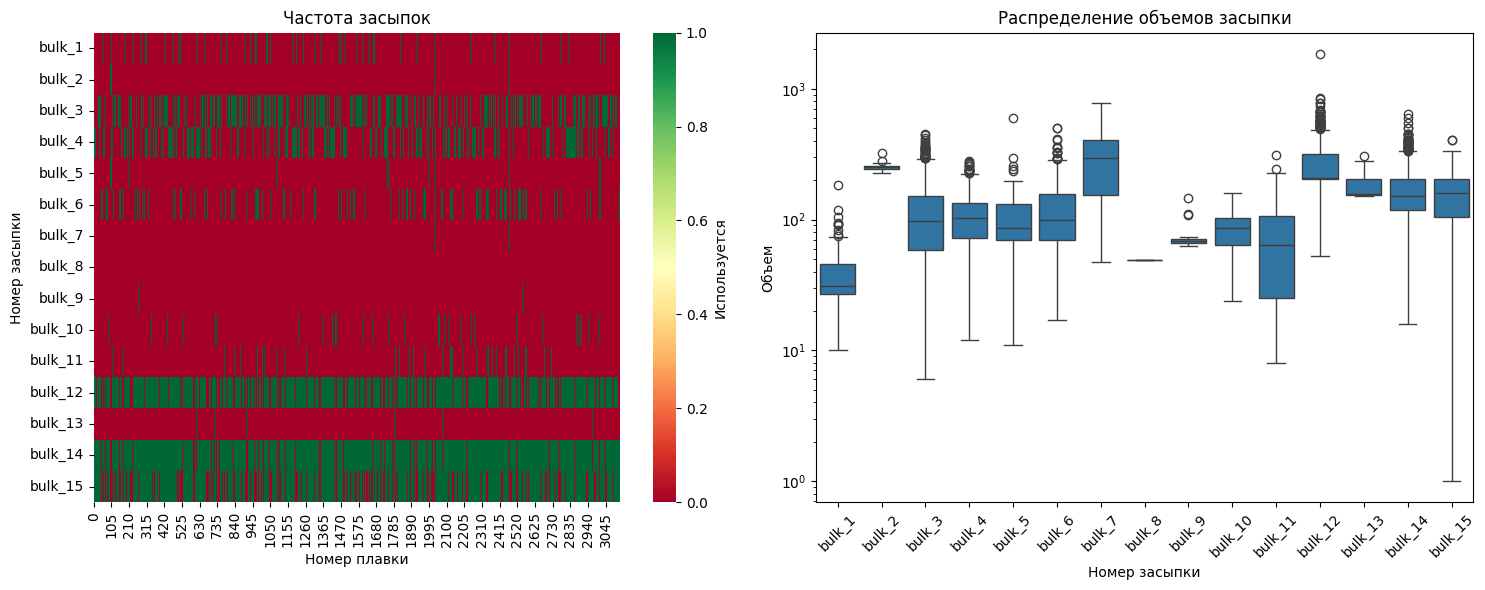

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Тепловая карта засыпок
usage_matrix = pd.DataFrame({f'bulk_{i}': (df_bulk[f'bulk_{i}'] > 0).astype(int) 
                              for i in range(1, 16)})
sns.heatmap(usage_matrix.T, cmap='RdYlGn', cbar_kws={'label': 'Используется'}, ax=axes[0])
axes[0].set_title('Частота засыпок')
axes[0].set_xlabel('Номер плавки')
axes[0].set_ylabel('Номер засыпки')

# Распределение объемов
data_for_box = df_bulk[[f'bulk_{i}' for i in range(1, 16)]].melt(var_name='Номер засыпки', value_name='Объем')
data_for_box = data_for_box[data_for_box['Объем'] > 0]
sns.boxplot(data=data_for_box, x='Номер засыпки', y='Объем', ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('Распределение объемов засыпки')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Посмотрим отдельно на выброс засыпки в номере 12  
Именно номер плавки по порядку, непонятно

In [30]:
df_bulk.head()

,key,bulk_1,bulk_2,bulk_3,bulk_4,bulk_5,bulk_6,bulk_7,bulk_8,bulk_9,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15
0,1,NaN,NaN,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,150.0,154.0
1,2,NaN,NaN,NaN,73.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,149.0,154.0
2,3,NaN,NaN,NaN,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.0,NaN,152.0,153.0
3,4,NaN,NaN,NaN,81.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,207.0,NaN,153.0,154.0
4,5,NaN,NaN,NaN,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203.0,NaN,151.0,152.0


In [31]:
display(df_bulk[df_bulk['bulk_12'] > 600])

,key,bulk_1,bulk_2,bulk_3,bulk_4,bulk_5,bulk_6,bulk_7,bulk_8,bulk_9,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15
11,12,46.0,NaN,NaN,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,618.0,NaN,406.0,203.0
207,223,NaN,NaN,124.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,666.0,NaN,316.0,202.0
303,322,185.0,NaN,101.0,58.0,NaN,NaN,406.0,NaN,NaN,NaN,NaN,1849.0,NaN,636.0,NaN
308,327,67.0,NaN,NaN,119.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,775.0,NaN,403.0,205.0
418,444,52.0,NaN,NaN,115.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,671.0,NaN,379.0,203.0
841,877,90.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,85.0,NaN,669.0,NaN,102.0,NaN
960,1005,31.0,NaN,147.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,668.0,NaN,198.0,205.0
1005,1050,46.0,NaN,NaN,NaN,NaN,109.0,NaN,NaN,NaN,NaN,29.0,647.0,NaN,371.0,103.0
1175,1224,31.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,668.0,NaN,213.0,NaN
1240,1290,44.0,NaN,61.0,65.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,609.0,NaN,275.0,158.0


Непонятно все равно, может быть и есть в этом какая-то логика, но мне она отсюда не видна.  
Лучше сделаем новые фичи:  
1) Суммарный объем засыпок;  
2) Число засыпок;  

In [32]:
bulk_cols = [col for col in df_bulk.columns if 'bulk_' in col.lower()]
df_bulk['total_bulk'] = df_bulk[bulk_cols].sum(axis=1)

In [33]:
df_bulk['count_bulk'] = df_bulk[bulk_cols].count(axis=1)

In [34]:
df_bulk.head()

,key,bulk_1,bulk_2,bulk_3,bulk_4,bulk_5,bulk_6,bulk_7,bulk_8,bulk_9,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15,total_bulk,count_bulk
0,1,NaN,NaN,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,150.0,154.0,553.0,4
1,2,NaN,NaN,NaN,73.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,149.0,154.0,582.0,4
2,3,NaN,NaN,NaN,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.0,NaN,152.0,153.0,544.0,4
3,4,NaN,NaN,NaN,81.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,207.0,NaN,153.0,154.0,595.0,4
4,5,NaN,NaN,NaN,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203.0,NaN,151.0,152.0,584.0,4


2026-03-03 22:10:02 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-03 22:10:02 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


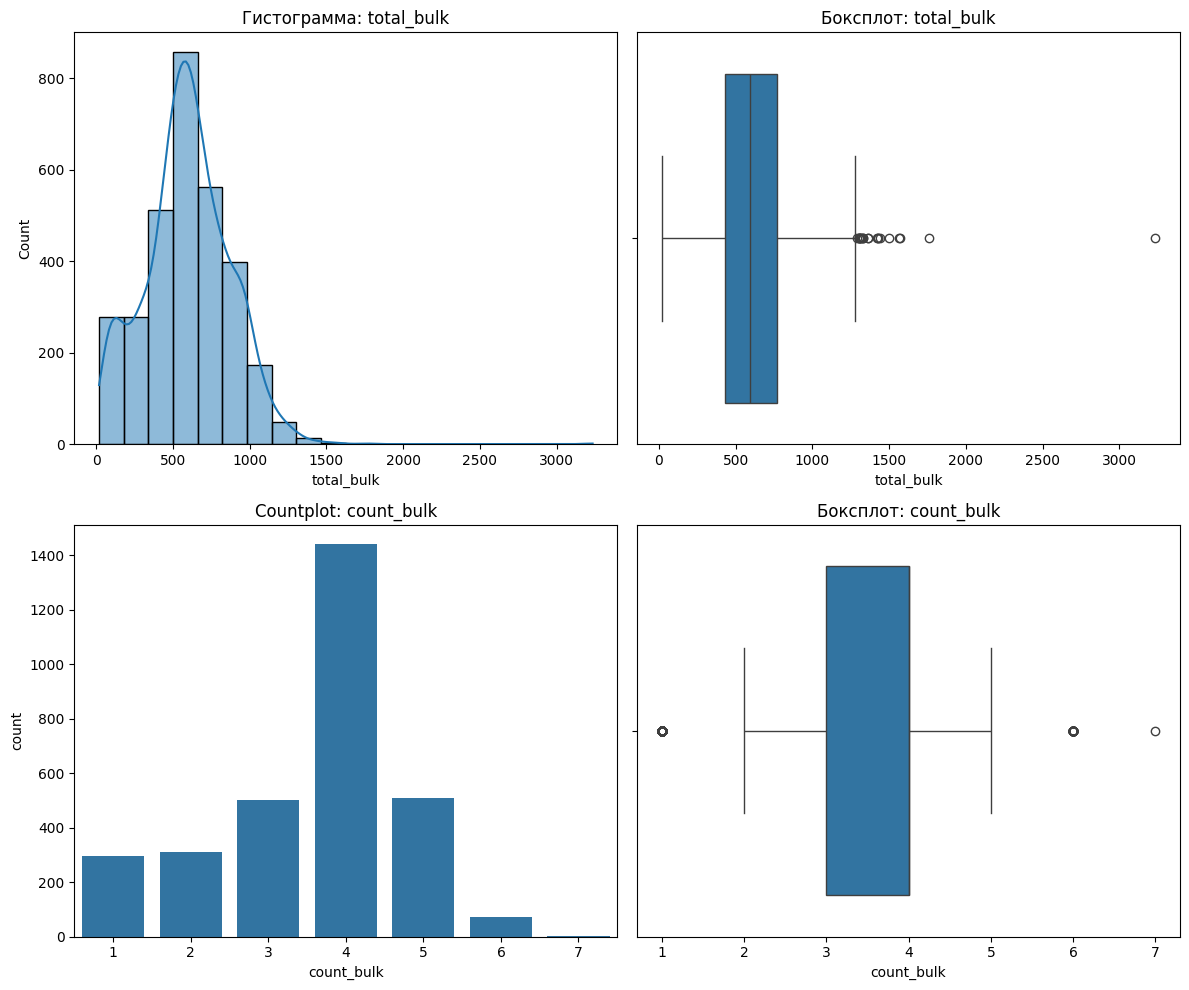

In [35]:
# и посмотрим что вышло
cols = ['total_bulk', 'count_bulk']
plot_combined(df_bulk, col=cols, target=None, col_type=None, legend_loc='best')

In [36]:
df_bulk = df_bulk.fillna(0)

##### df_bulk_time

2026-03-03 22:10:02 [INFO] __main__: Общая информация базы данных


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   key      3129 non-null   int64 
 1   bulk_1   252 non-null    object
 2   bulk_2   22 non-null     object
 3   bulk_3   1298 non-null   object
 4   bulk_4   1014 non-null   object
 5   bulk_5   77 non-null     object
 6   bulk_6   576 non-null    object
 7   bulk_7   25 non-null     object
 8   bulk_8   1 non-null      object
 9   bulk_9   19 non-null     object
 10  bulk_10  176 non-null    object
 11  bulk_11  177 non-null    object
 12  bulk_12  2450 non-null   object
 13  bulk_13  18 non-null     object
 14  bulk_14  2806 non-null   object
 15  bulk_15  2248 non-null   object
dtypes: int64(1), object(15)
memory usage: 391.3+ KB


None

2026-03-03 22:10:02 [INFO] __main__: 5 случайных строк


,key,bulk_1,bulk_2,bulk_3,bulk_4,bulk_5,bulk_6,bulk_7,bulk_8,bulk_9,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15
1844,1906,None,None,None,2019-07-18 15:44:44,None,None,None,None,None,None,None,2019-07-18 15:48:46,None,2019-07-18 15:44:44,2019-07-18 15:28:44
2568,2666,None,None,None,None,None,2019-08-16 22:18:17,None,None,None,None,2019-08-16 22:25:25,2019-08-16 22:25:25,None,2019-08-16 22:18:17,2019-08-16 22:13:09
519,548,None,None,2019-05-24 10:14:45,None,None,2019-05-24 10:10:29,None,None,None,None,None,2019-05-24 10:05:19,None,2019-05-24 09:59:21,None
128,141,None,None,None,None,None,None,None,None,None,None,None,2019-05-09 00:59:46,None,2019-05-09 00:51:53,None
1095,1143,None,None,None,2019-06-16 03:00:22,None,None,None,None,None,None,None,2019-06-16 02:55:59,None,2019-06-16 02:47:00,2019-06-16 02:42:44


2026-03-03 22:10:02 [INFO] __main__: Число пропусков в базе данных


bulk_1     2877
bulk_2     3107
bulk_3     1831
bulk_4     2115
bulk_5     3052
bulk_6     2553
bulk_7     3104
bulk_8     3128
bulk_9     3110
bulk_10    2953
bulk_11    2952
bulk_12     679
bulk_13    3111
bulk_14     323
bulk_15     881
dtype: int64

None

2026-03-03 22:10:02 [INFO] __main__: Визуализация пропусков


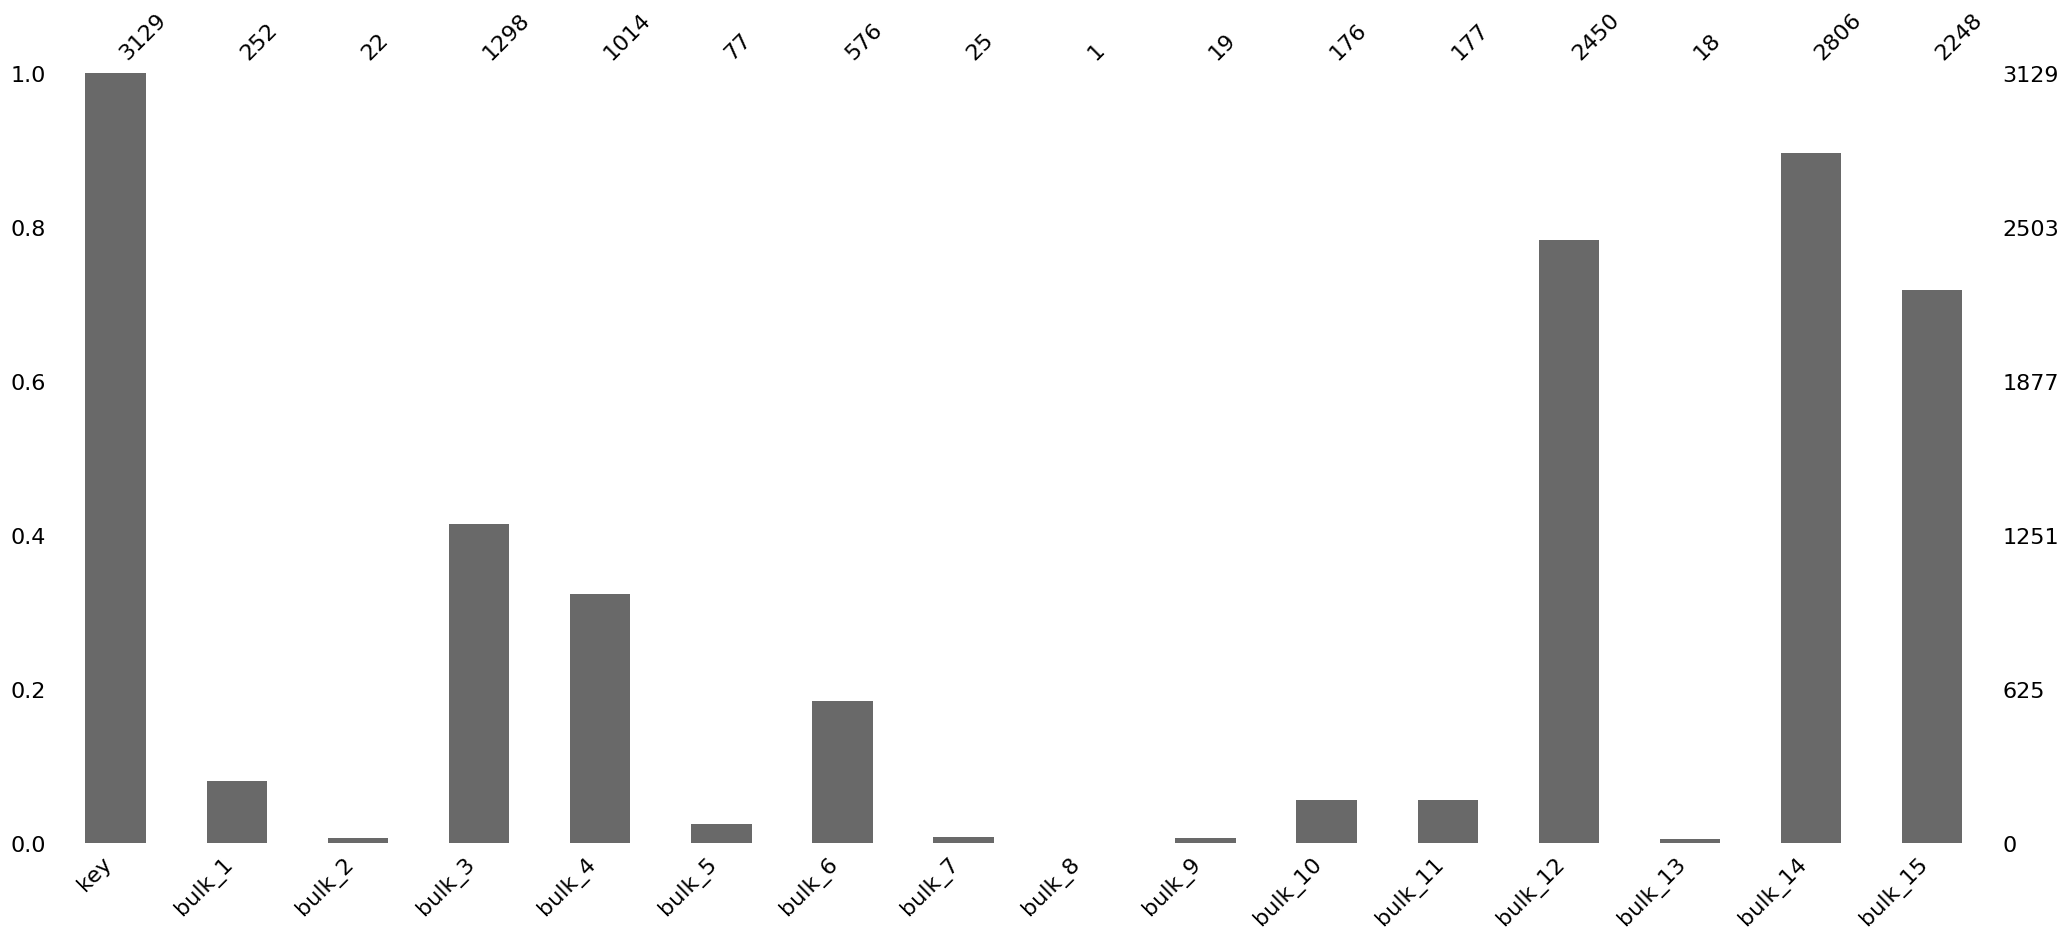

2026-03-03 22:10:02 [INFO] __main__: Характеристики базы данных


,count,mean,std,min,25%,50%,75%,max
key,3129.0,1624.383509,933.337642,1.0,816.0,1622.0,2431.0,3241.0


In [37]:
df_bulk_time = check_data(df_bulk_time)

Аналогично и тут пропуски - время подачи, т.к. не было подачи по факту то и не было фиксации времени  
Здесь видимо пропуски будут NaT

In [38]:
bulk_time_cols = [col for col in df_bulk_time.columns if 'bulk_' in col.lower()]
df_bulk_time[bulk_time_cols] = df_bulk_time[bulk_time_cols].astype('datetime64[ns]')

In [39]:
df_bulk_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   key      3129 non-null   int64         
 1   bulk_1   252 non-null    datetime64[ns]
 2   bulk_2   22 non-null     datetime64[ns]
 3   bulk_3   1298 non-null   datetime64[ns]
 4   bulk_4   1014 non-null   datetime64[ns]
 5   bulk_5   77 non-null     datetime64[ns]
 6   bulk_6   576 non-null    datetime64[ns]
 7   bulk_7   25 non-null     datetime64[ns]
 8   bulk_8   1 non-null      datetime64[ns]
 9   bulk_9   19 non-null     datetime64[ns]
 10  bulk_10  176 non-null    datetime64[ns]
 11  bulk_11  177 non-null    datetime64[ns]
 12  bulk_12  2450 non-null   datetime64[ns]
 13  bulk_13  18 non-null     datetime64[ns]
 14  bulk_14  2806 non-null   datetime64[ns]
 15  bulk_15  2248 non-null   datetime64[ns]
dtypes: datetime64[ns](15), int64(1)
memory usage: 391.3 KB


In [40]:
df_bulk_time.head()

,key,bulk_1,bulk_2,bulk_3,bulk_4,bulk_5,bulk_6,bulk_7,bulk_8,bulk_9,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15
0,1,NaT,NaT,NaT,2019-05-03 11:28:48,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:24:31,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2,NaT,NaT,NaT,2019-05-03 11:36:50,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:53:30,NaT,2019-05-03 11:48:37,2019-05-03 11:44:39
2,3,NaT,NaT,NaT,2019-05-03 12:32:39,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 12:27:13,NaT,2019-05-03 12:21:01,2019-05-03 12:16:16
3,4,NaT,NaT,NaT,2019-05-03 12:43:22,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 12:58:00,NaT,2019-05-03 12:51:11,2019-05-03 12:46:36
4,5,NaT,NaT,NaT,2019-05-03 13:30:47,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 13:30:47,NaT,2019-05-03 13:34:12,2019-05-03 13:30:47


Интересное наблюдение, отсчет идет с последней засыпке к 1й...   
Ну да пусть, нам бы посчитать суммарное время  

In [41]:
df_bulk_time['начало_засыпок'] = df_bulk_time[bulk_time_cols].min(axis=1)
df_bulk_time['конец_засыпок'] = df_bulk_time[bulk_time_cols].max(axis=1)
df_bulk_time['общее_время_засыпок'] = (df_bulk_time['конец_засыпок'] - df_bulk_time['начало_засыпок']).dt.total_seconds()

In [42]:
# ну и средний интервал между подачами заодно

df_bulk_time['интервал_подачи_avg'] = (
    df_bulk_time[bulk_time_cols]
    .apply(lambda row: row.dropna().sort_values().diff().dt.total_seconds().mean(), axis=1)
)

In [43]:
display(df_bulk_time.head())
display(df_bulk_time.info())
display(df_bulk_time.describe().T)

,key,bulk_1,bulk_2,bulk_3,bulk_4,bulk_5,bulk_6,bulk_7,bulk_8,bulk_9,bulk_10,bulk_11,bulk_12,bulk_13,bulk_14,bulk_15,начало_засыпок,конец_засыпок,общее_время_засыпок,интервал_подачи_avg
0,1,NaT,NaT,NaT,2019-05-03 11:28:48,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:24:31,NaT,2019-05-03 11:14:50,2019-05-03 11:10:43,2019-05-03 11:10:43,2019-05-03 11:28:48,1085.0,361.666667
1,2,NaT,NaT,NaT,2019-05-03 11:36:50,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:53:30,NaT,2019-05-03 11:48:37,2019-05-03 11:44:39,2019-05-03 11:36:50,2019-05-03 11:53:30,1000.0,333.333333
2,3,NaT,NaT,NaT,2019-05-03 12:32:39,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 12:27:13,NaT,2019-05-03 12:21:01,2019-05-03 12:16:16,2019-05-03 12:16:16,2019-05-03 12:32:39,983.0,327.666667
3,4,NaT,NaT,NaT,2019-05-03 12:43:22,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 12:58:00,NaT,2019-05-03 12:51:11,2019-05-03 12:46:36,2019-05-03 12:43:22,2019-05-03 12:58:00,878.0,292.666667
4,5,NaT,NaT,NaT,2019-05-03 13:30:47,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 13:30:47,NaT,2019-05-03 13:34:12,2019-05-03 13:30:47,2019-05-03 13:30:47,2019-05-03 13:34:12,205.0,68.333333


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   key                  3129 non-null   int64         
 1   bulk_1               252 non-null    datetime64[ns]
 2   bulk_2               22 non-null     datetime64[ns]
 3   bulk_3               1298 non-null   datetime64[ns]
 4   bulk_4               1014 non-null   datetime64[ns]
 5   bulk_5               77 non-null     datetime64[ns]
 6   bulk_6               576 non-null    datetime64[ns]
 7   bulk_7               25 non-null     datetime64[ns]
 8   bulk_8               1 non-null      datetime64[ns]
 9   bulk_9               19 non-null     datetime64[ns]
 10  bulk_10              176 non-null    datetime64[ns]
 11  bulk_11              177 non-null    datetime64[ns]
 12  bulk_12              2450 non-null   datetime64[ns]
 13  bulk_13              18 non-null 

None

,count,mean,min,25%,50%,75%,max,std
key,3129.0,1624.383509,1.0,816.0,1622.0,2431.0,3241.0,933.337642
bulk_1,252,2019-06-29 23:24:44.769841152,2019-05-03 17:42:46,2019-05-29 14:48:48.500000,2019-06-25 11:09:13,2019-07-31 05:58:18.249999872,2019-09-05 09:11:32,NaN
bulk_2,22,2019-07-12 07:57:13.045454592,2019-05-07 15:39:35,2019-05-28 02:29:31.500000,2019-07-27 17:18:38.500000,2019-08-13 02:20:08,2019-08-13 11:47:39,NaN
bulk_3,1298,2019-07-08 13:50:14.630970624,2019-05-03 20:40:25,2019-06-08 03:50:23.500000,2019-07-04 09:31:42,2019-08-11 01:00:36.750000128,2019-09-06 12:26:52,NaN
bulk_4,1014,2019-07-03 11:17:28.834319616,2019-05-03 11:28:48,2019-05-30 21:36:11.249999872,2019-06-28 03:44:42.500000,2019-08-04 04:15:46.500000,2019-09-05 03:35:21,NaN
bulk_5,77,2019-07-13 17:18:29.090908928,2019-05-07 15:19:17,2019-06-19 23:32:44,2019-07-25 17:59:41,2019-08-13 04:23:23,2019-09-02 18:16:52,NaN
bulk_6,576,2019-07-06 13:50:06.345486080,2019-05-03 19:09:15,2019-06-06 22:46:10.500000,2019-07-09 03:34:57.500000,2019-08-07 18:55:01.249999872,2019-09-06 16:24:28,NaN
bulk_7,25,2019-07-27 18:09:05.079999744,2019-05-07 18:11:01,2019-07-20 23:48:47,2019-07-27 18:07:02,2019-08-13 04:19:43,2019-09-05 19:07:49,NaN
bulk_8,1,2019-07-08 17:14:53,2019-07-08 17:14:53,2019-07-08 17:14:53,2019-07-08 17:14:53,2019-07-08 17:14:53,2019-07-08 17:14:53,NaN
bulk_9,19,2019-06-23 08:08:47.578947328,2019-05-14 11:57:58,2019-05-14 14:31:08,2019-05-14 16:55:09,2019-08-16 05:43:31,2019-08-16 09:11:56,NaN


Вылезла неадекватная продолжительность подачи, посмотрим поближе

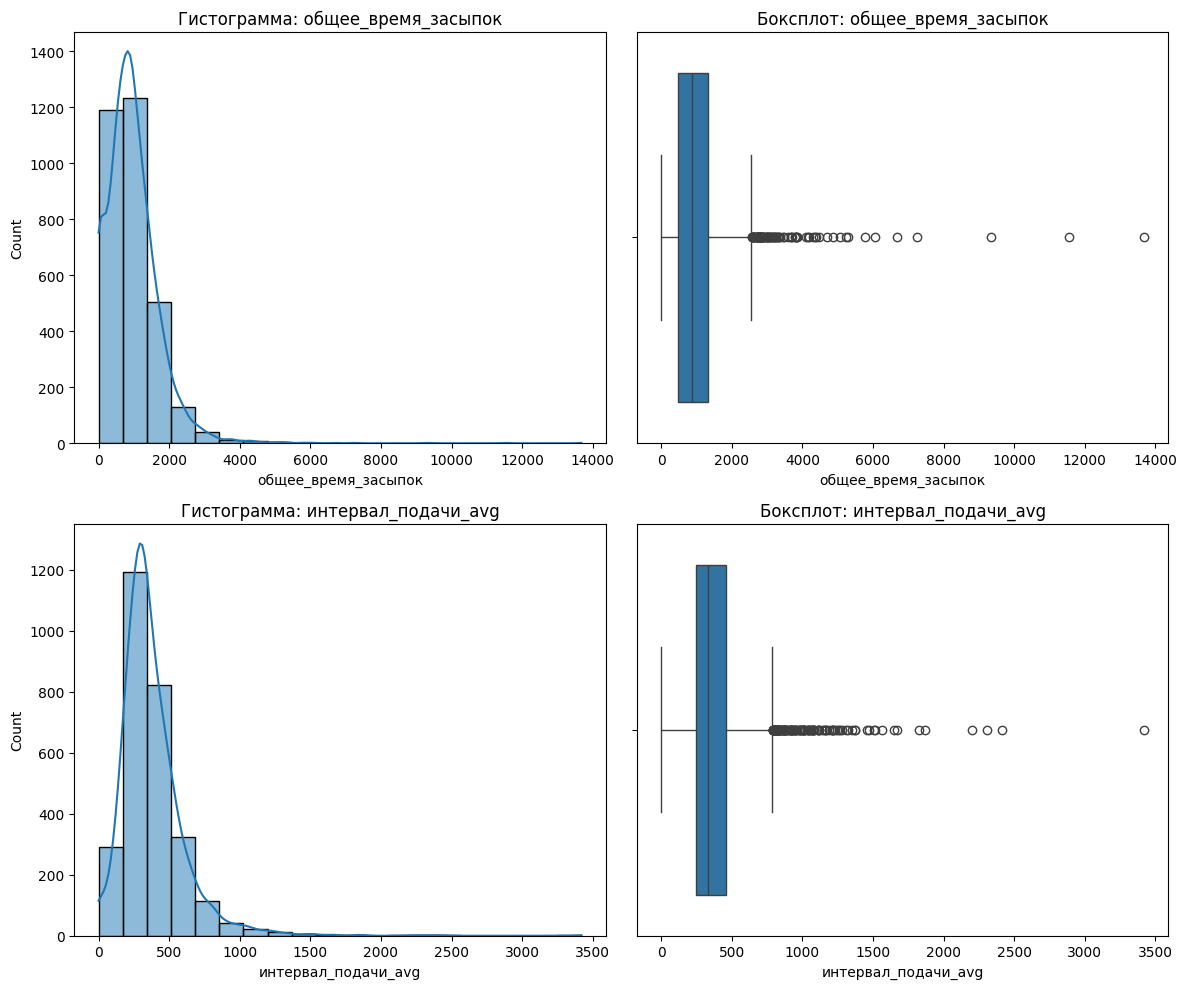

In [44]:
# и посмотрим что вышло
cols = ['общее_время_засыпок', 'интервал_подачи_avg']
plot_combined(df_bulk_time, col=cols, target=None, col_type=None, legend_loc='best')

##### df_gas

In [45]:
df_gas = check_data(df_gas)

2026-03-03 22:10:04 [INFO] __main__: Общая информация базы данных


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3239 entries, 0 to 3238
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3239 non-null   int64  
 1   газ_1   3239 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 50.7 KB


None

2026-03-03 22:10:04 [INFO] __main__: 5 случайных строк


,key,газ_1
288,291,17.724259
139,140,18.016613
1562,1565,5.099318
919,922,11.793956
993,996,8.838195


2026-03-03 22:10:04 [INFO] __main__: Число пропусков в базе данных


Series([], dtype: int64)

None

2026-03-03 22:10:04 [INFO] __main__: Характеристики базы данных


,count,mean,std,min,25%,50%,75%,max
key,3239.0,1621.861377,935.386334,1.000000,812.500000,1622.000000,2431.500000,3241.00000
газ_1,3239.0,11.002062,6.220327,0.008399,7.043089,9.836267,13.769915,77.99504


Тут на первый взгляд все у нас хорошо  
но посмотрим и на график

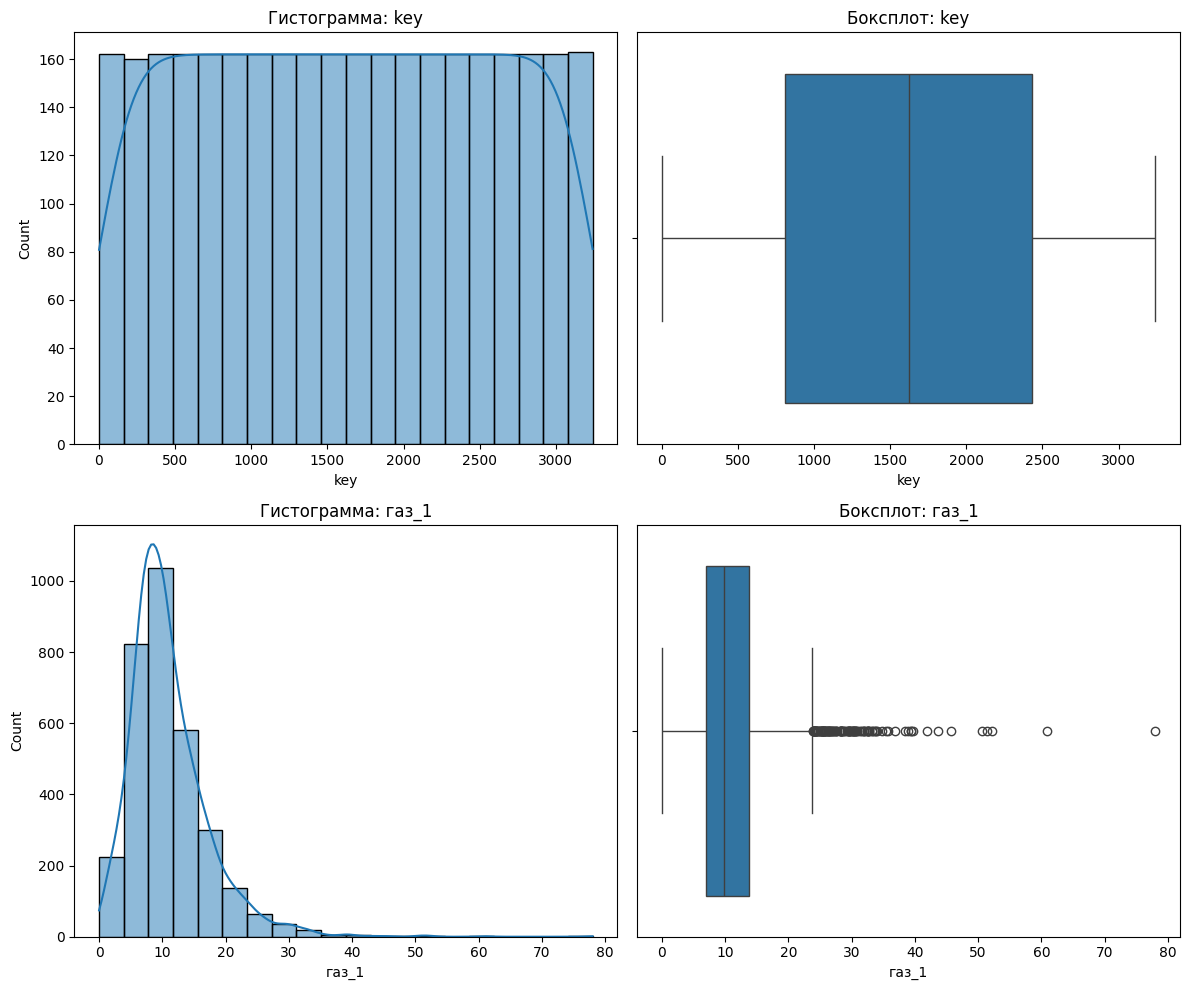

In [46]:
plot_combined(df_gas, col=None, target=None, col_type=None, legend_loc='best')

Не такой больше различие у максимума, но все равно посмотрим на бОльшие значения

In [47]:
display(df_gas[df_gas['газ_1'] > 50])

,key,газ_1
116,117,50.581035
277,280,60.935689
319,322,77.995040
2107,2110,52.142373
2567,2570,51.380229


Ну дали чутка больше газа и ладно, бывает

##### df_temp

2026-03-03 22:10:05 [INFO] __main__: Общая информация базы данных


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18092 entries, 0 to 18091
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   key           18092 non-null  int64 
 1   время_замера  18092 non-null  object
 2   температура   14665 non-null  object
dtypes: int64(1), object(2)
memory usage: 424.2+ KB


None

2026-03-03 22:10:05 [INFO] __main__: 5 случайных строк


,key,время_замера,температура
8649,1546,2019-06-30 17:09:20,1599.0
1595,286,2019-05-14 15:20:15,1602.0
10642,1903,2019-07-18 12:11:49,1597.0
10104,1809,2019-07-09 16:24:29,1610.0
10737,1921,2019-07-19 09:35:42,1612.0


2026-03-03 22:10:05 [INFO] __main__: Число пропусков в базе данных


температура    3427
dtype: int64

None

2026-03-03 22:10:05 [INFO] __main__: Визуализация пропусков


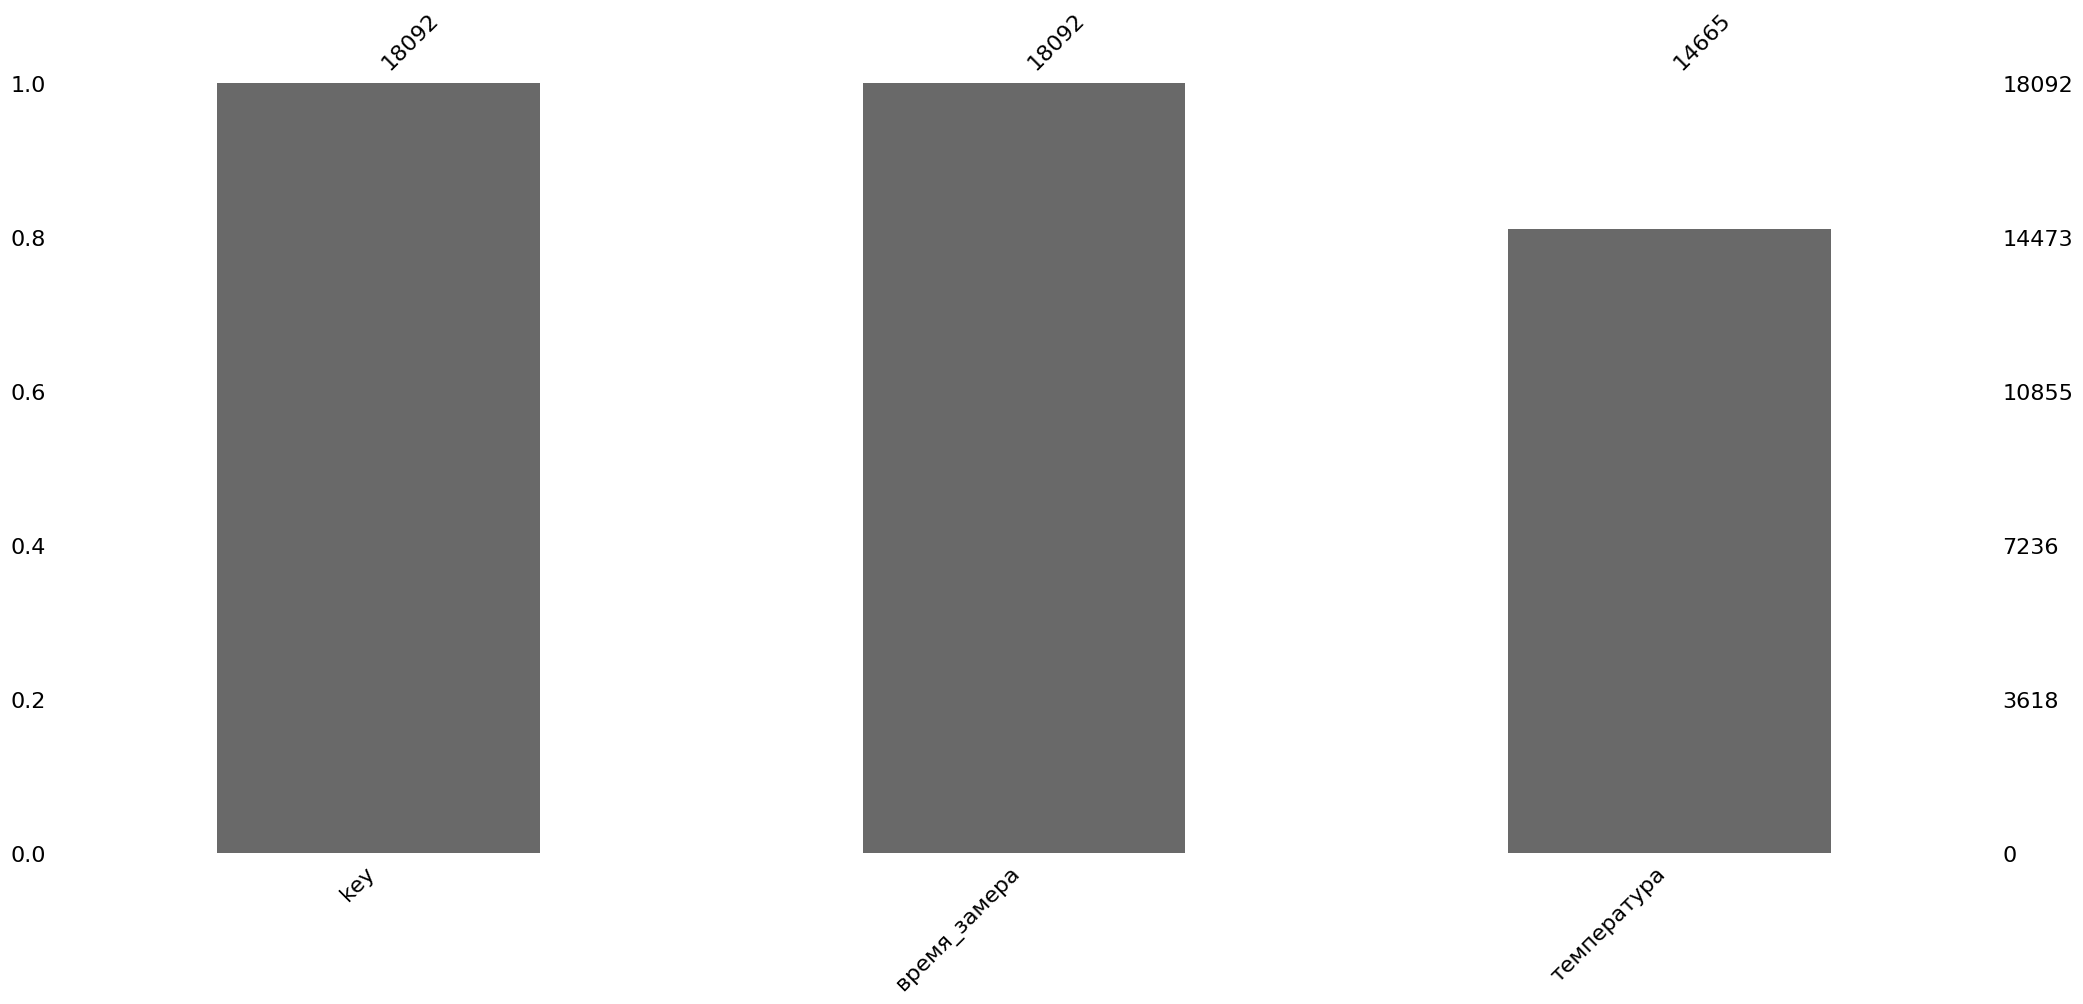

2026-03-03 22:10:05 [INFO] __main__: Характеристики базы данных


,count,mean,std,min,25%,50%,75%,max
key,18092.0,1616.460977,934.641385,1.0,807.75,1618.0,2429.0,3241.0


In [48]:
df_temp = check_data(df_temp)

У времени сделать нормальный тип данных  
Пропуски мы не сможем адекватно скорректировать  
Как эксперимент можем взять два соседних тайминга и просто взять среднюю между этими числами, критической проблемы тут быть не должно  
PS: изучив данные мы видим, что там на каждый key только один замер температур

In [49]:
# df_temp['температура'] = df_temp['температура'].fillna(-1).astype('float64')
df_temp['температура'] = df_temp['температура'].astype('float64')

In [50]:
df_temp['время_замера'] = df_temp['время_замера'].astype('datetime64[ns]')

In [51]:
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18092 entries, 0 to 18091
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   key           18092 non-null  int64         
 1   время_замера  18092 non-null  datetime64[ns]
 2   температура   14665 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 424.2 KB


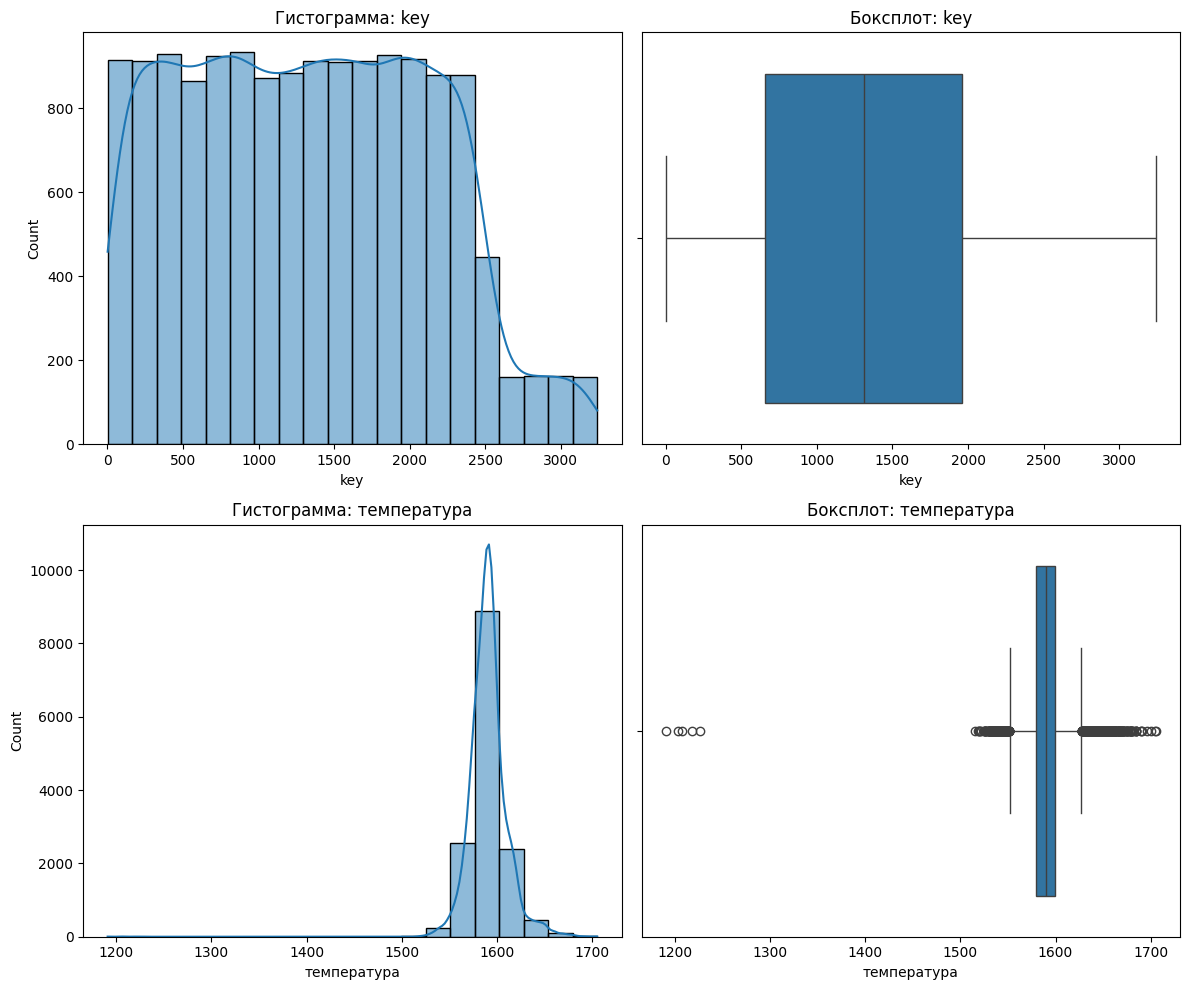

In [52]:
temp_df_temp = df_temp[df_temp['температура'] > 0]
plot_combined(temp_df_temp, col=None, target=None, col_type=None, legend_loc='best')

In [53]:
temp_df_temp.describe().T

,count,mean,min,25%,50%,75%,max,std
key,14665.0,1325.484214,1.0,654.0,1314.0,1963.0,3241.0,787.375969
время_замера,14665,2019-06-23 23:59:11.606341632,2019-05-03 11:02:04,2019-05-28 23:56:49,2019-06-21 22:55:49,2019-07-21 22:58:20,2019-09-06 16:48:55,NaN
температура,14665.0,1590.722741,1191.0,1580.0,1590.0,1599.0,1705.0,20.394381


В целом распределение температур выглядит адекватно

Что касается задания -  
1) таргет - последняя температура партии  
2) можно брать только те позиции, где есть начальная и конечная температура, т.е. минимум 2 позиции  
3) промежуточные - не брать, это утечка данных  
4) температура ниже 1500 - аномалия

In [54]:
# посмотрим исходя из вводных от заказчика
# уберем сразу аномалии
df_temp = df_temp[df_temp['температура'] >= 1500]

In [55]:
df_temp = df_temp.groupby('key').agg(
    время_первого_замера = ('время_замера', 'min'),
    время_последнего_замера = ('время_замера', 'max'),
    стартовая_температура = ('температура', 'min'),
    конечная_температура = ('температура', 'max')
)
display(df_temp.head())

,время_первого_замера,время_последнего_замера,стартовая_температура,конечная_температура
key,,,,
1,2019-05-03 11:02:04,2019-05-03 11:30:38,1571.0,1618.0
2,2019-05-03 11:34:04,2019-05-03 11:55:09,1577.0,1604.0
3,2019-05-03 12:06:44,2019-05-03 12:35:57,1596.0,1600.0
4,2019-05-03 12:39:27,2019-05-03 12:59:47,1601.0,1625.0
5,2019-05-03 13:11:03,2019-05-03 13:36:39,1576.0,1602.0


##### df_wire

2026-03-03 22:10:05 [INFO] __main__: Общая информация базы данных


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3081 non-null   int64  
 1   wire_1  3055 non-null   float64
 2   wire_2  1079 non-null   object 
 3   wire_3  63 non-null     object 
 4   wire_4  14 non-null     object 
 5   wire_5  1 non-null      object 
 6   wire_6  73 non-null     object 
 7   wire_7  11 non-null     object 
 8   wire_8  19 non-null     object 
 9   wire_9  29 non-null     object 
dtypes: float64(1), int64(1), object(8)
memory usage: 240.8+ KB


None

2026-03-03 22:10:05 [INFO] __main__: 5 случайных строк


,key,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9
306,329,183.362397,None,None,None,None,None,None,None,None
2932,3091,143.052001,None,283.242963,None,None,None,None,None,None
1463,1539,20.077200,20.086559,None,None,None,None,None,None,None
564,599,109.184403,None,None,None,None,None,None,None,None
503,537,100.011597,None,None,None,None,None,None,None,None


2026-03-03 22:10:05 [INFO] __main__: Число пропусков в базе данных


wire_1      26
wire_2    2002
wire_3    3018
wire_4    3067
wire_5    3080
wire_6    3008
wire_7    3070
wire_8    3062
wire_9    3052
dtype: int64

None

2026-03-03 22:10:05 [INFO] __main__: Визуализация пропусков


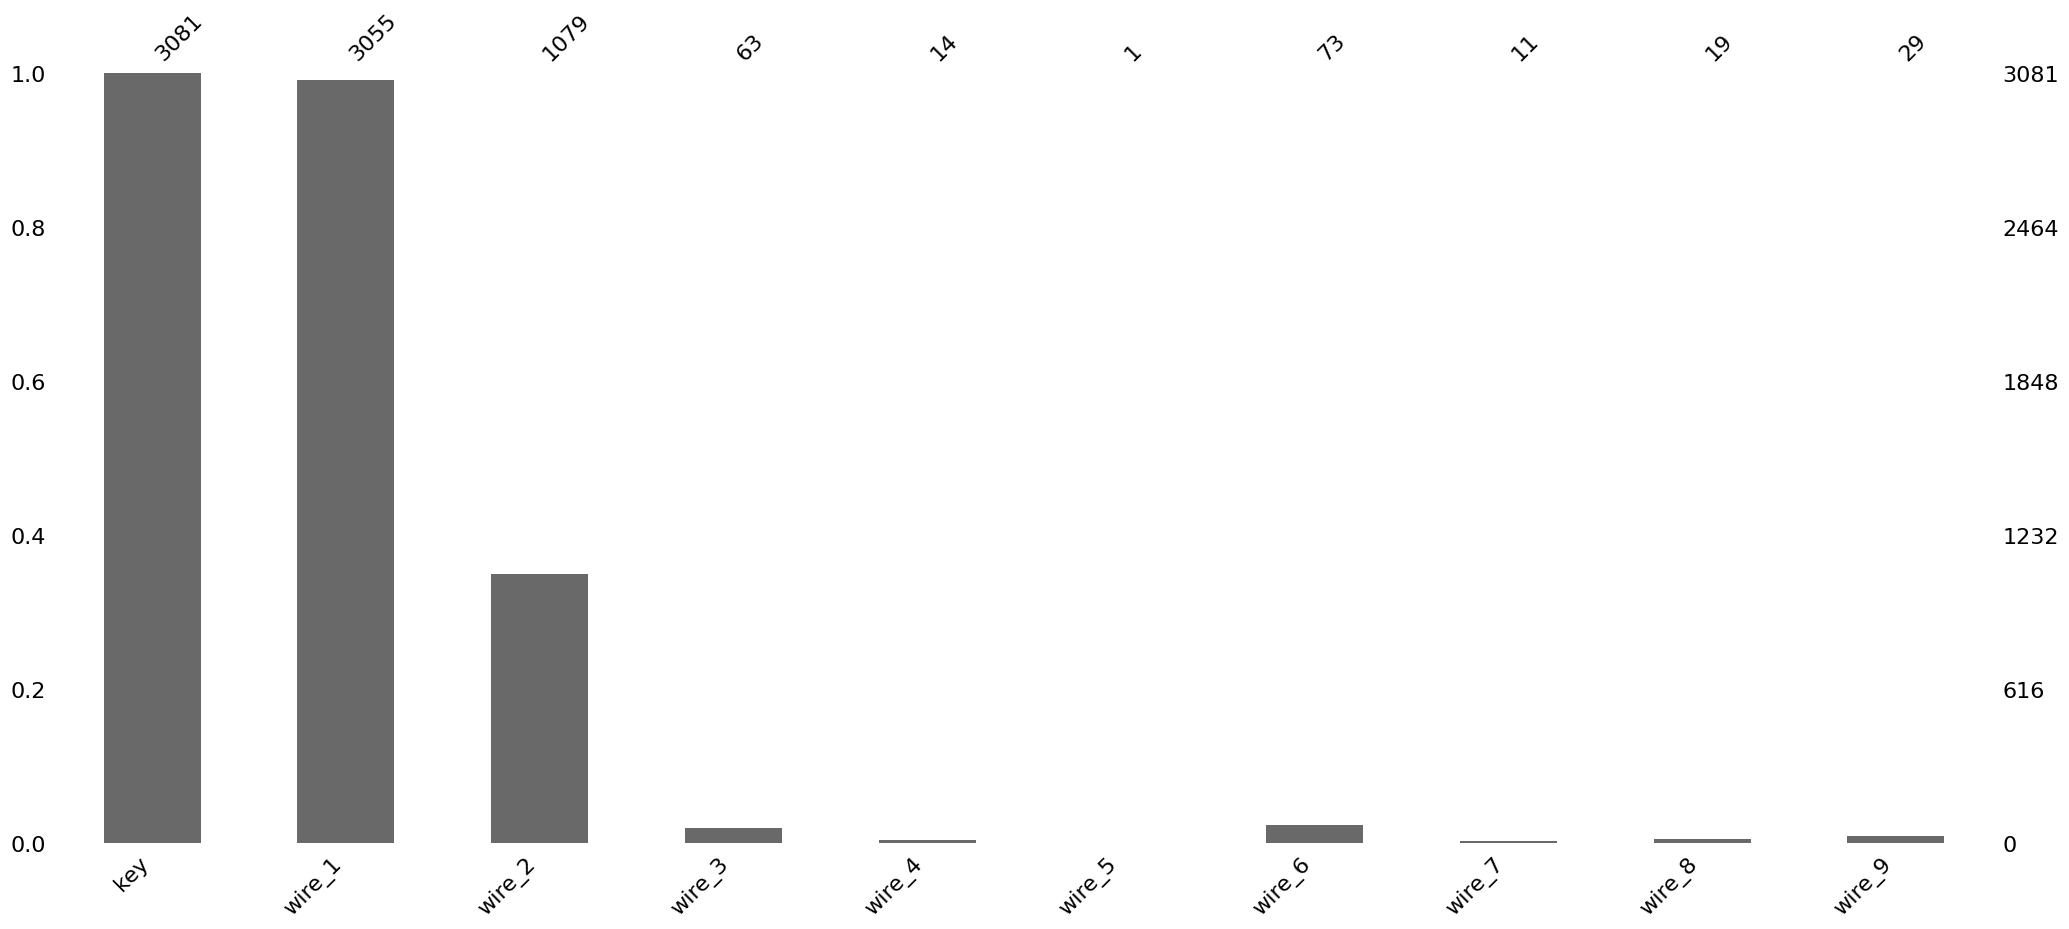

2026-03-03 22:10:06 [INFO] __main__: Характеристики базы данных


,count,mean,std,min,25%,50%,75%,max
key,3081.0,1623.426485,932.996726,1.0000,823.000000,1619.000000,2434.000000,3241.000000
wire_1,3055.0,100.895853,42.012518,1.9188,72.115684,100.158234,126.060483,330.314424


In [56]:
df_wire = check_data(df_wire)

Тут как и с сыпучими материалами - либо добавили, либо нет.  
Вместо пропусков - 0

In [57]:
for col in df_wire.columns:
    if col != 'key':
        df_wire[col] = df_wire[col].astype(float)

2026-03-03 22:10:06 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-03 22:10:06 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-03 22:10:06 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-03 22:10:06 [INFO] matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-03 22:10:06 [INFO] matplotlib.category: 

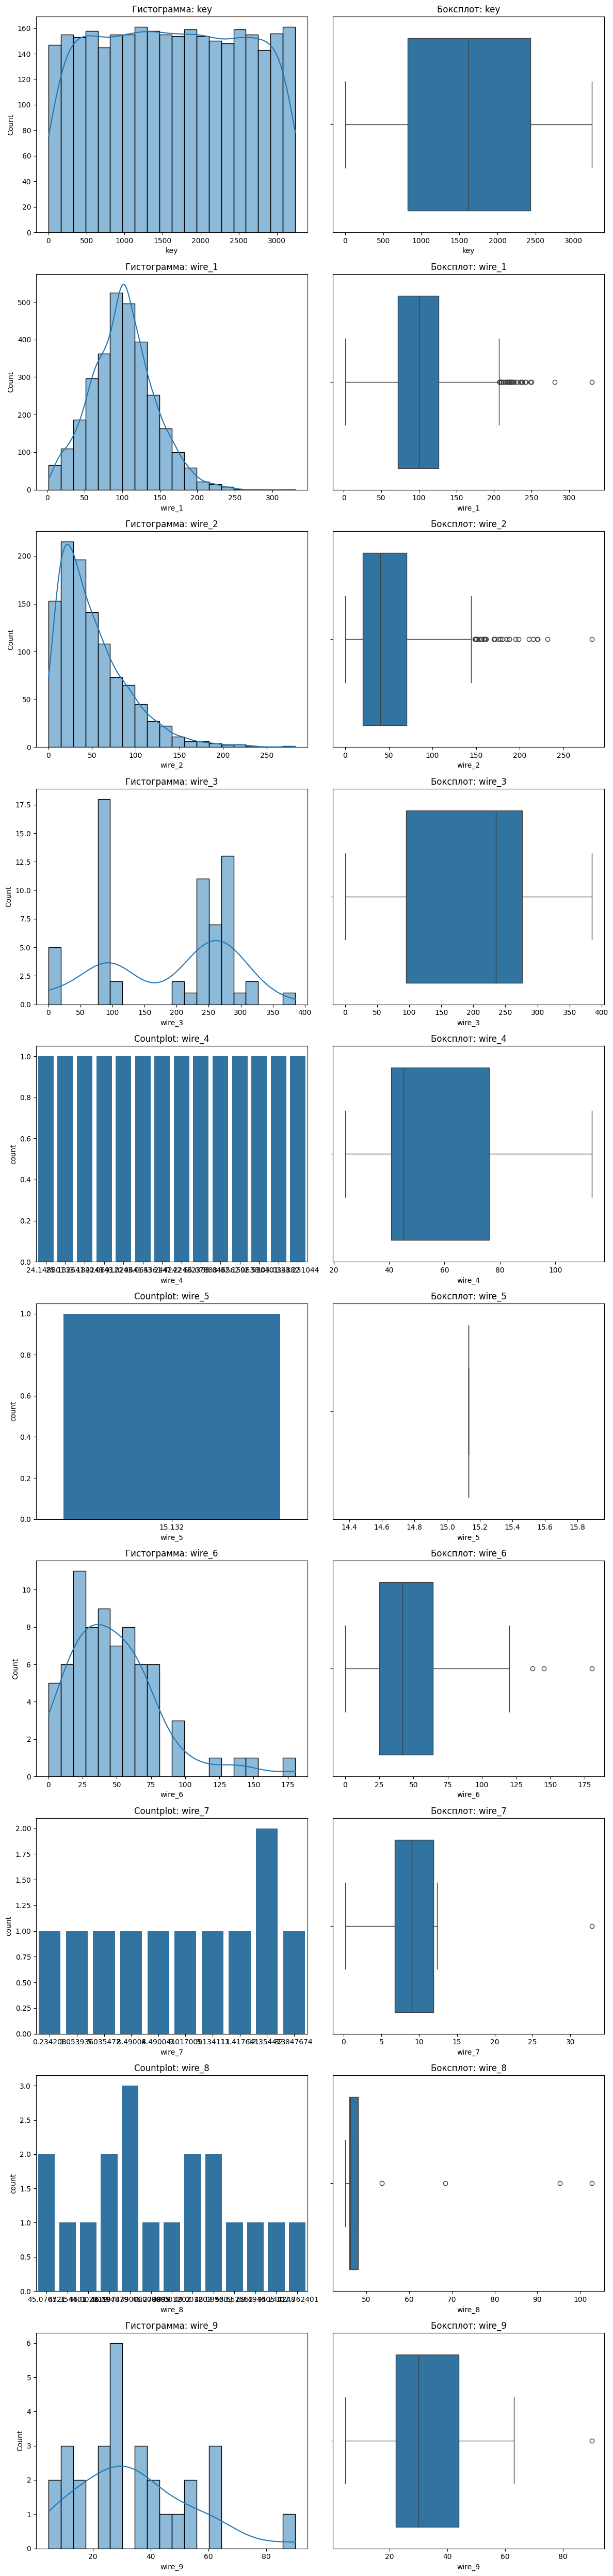

In [58]:
plot_combined(df_wire, col=None, target=None, col_type=None, legend_loc='best')

In [59]:
display(df_wire.info())
display(df_wire.head())
display(df_wire.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3081 non-null   int64  
 1   wire_1  3055 non-null   float64
 2   wire_2  1079 non-null   float64
 3   wire_3  63 non-null     float64
 4   wire_4  14 non-null     float64
 5   wire_5  1 non-null      float64
 6   wire_6  73 non-null     float64
 7   wire_7  11 non-null     float64
 8   wire_8  19 non-null     float64
 9   wire_9  29 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 240.8 KB


None

,key,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9
0,1,60.059998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,96.052315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,91.160157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,89.063515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,89.238236,9.11456,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count,mean,std,min,25%,50%,75%,max
key,3081.0,1623.426485,932.996726,1.000000,823.000000,1619.000000,2434.000000,3241.000000
wire_1,3055.0,100.895853,42.012518,1.918800,72.115684,100.158234,126.060483,330.314424
wire_2,1079.0,50.577323,39.320216,0.030160,20.193680,40.142956,70.227558,282.780152
wire_3,63.0,189.482681,99.513444,0.144144,95.135044,235.194977,276.252014,385.008668
wire_4,14.0,57.442841,28.824667,24.148801,40.807002,45.234282,76.124619,113.231044
wire_5,1.0,15.132000,NaN,15.132000,15.132000,15.132000,15.132000,15.132000
wire_6,73.0,48.016974,33.919845,0.034320,25.053600,42.076324,64.212723,180.454575
wire_7,11.0,10.039007,8.610584,0.234208,6.762756,9.017009,11.886057,32.847674
wire_8,19.0,53.625193,16.881728,45.076721,46.094879,46.279999,48.089603,102.762401
wire_9,29.0,34.155752,19.931616,4.622800,22.058401,30.066399,43.862003,90.053604


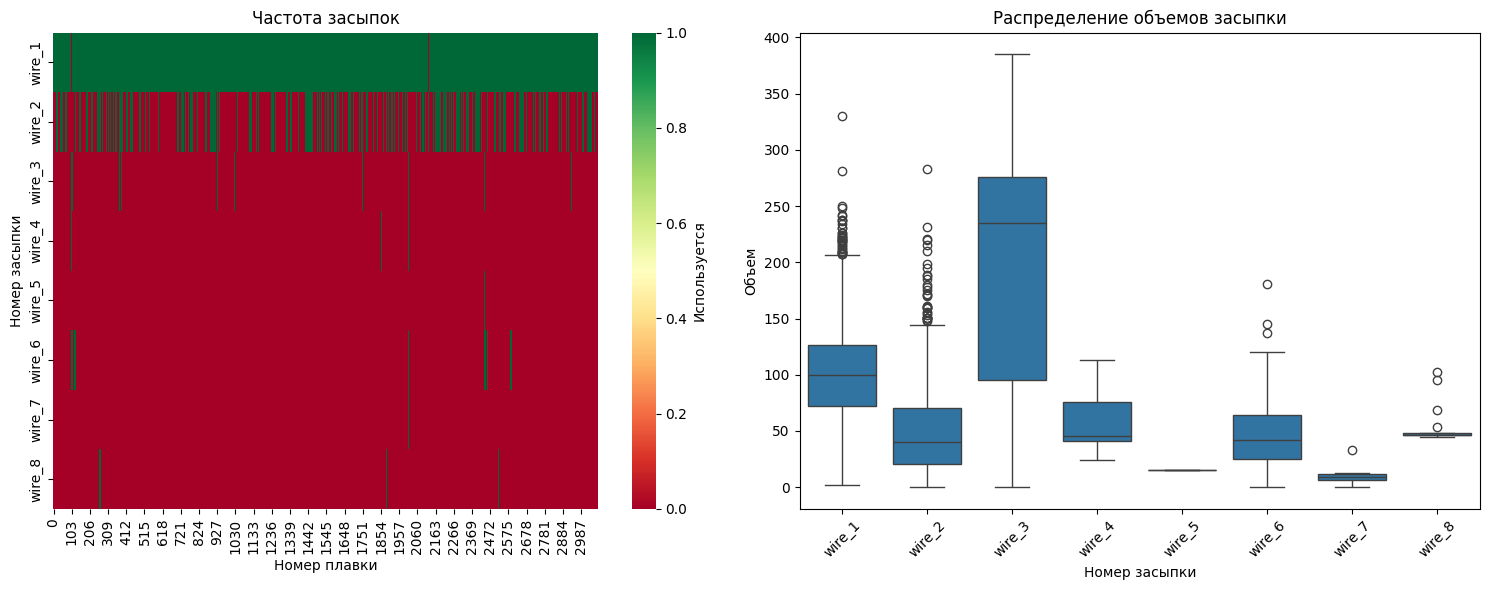

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Тепловая карта засыпок
usage_matrix = pd.DataFrame({f'wire_{i}': (df_wire[f'wire_{i}'] > 0).astype(int) 
                              for i in range(1, 9)})
sns.heatmap(usage_matrix.T, cmap='RdYlGn', cbar_kws={'label': 'Используется'}, ax=axes[0])
axes[0].set_title('Частота засыпок')
axes[0].set_xlabel('Номер плавки')
axes[0].set_ylabel('Номер засыпки')

# Распределение объемов
data_for_box = df_wire[[f'wire_{i}' for i in range(1, 9)]].melt(var_name='Номер засыпки', value_name='Объем')
data_for_box = data_for_box[data_for_box['Объем'] > 0]
sns.boxplot(data=data_for_box, x='Номер засыпки', y='Объем', ax=axes[1])
# axes[1].set_yscale('log')
axes[1].set_title('Распределение объемов засыпки')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Выборсы конечно же есть, но берем в расчте, что так надо  
В целом видно, что основная масса грузится в первые 2-3 этапа, а дальше уже мелкие корректировки

In [61]:
# Добьем нулями
df_wire = df_wire.fillna(0)

##### df_wire_time

2026-03-03 22:10:08 [INFO] __main__: Общая информация базы данных


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   key     3081 non-null   int64 
 1   wire_1  3055 non-null   object
 2   wire_2  1079 non-null   object
 3   wire_3  63 non-null     object
 4   wire_4  14 non-null     object
 5   wire_5  1 non-null      object
 6   wire_6  73 non-null     object
 7   wire_7  11 non-null     object
 8   wire_8  19 non-null     object
 9   wire_9  29 non-null     object
dtypes: int64(1), object(9)
memory usage: 240.8+ KB


None

2026-03-03 22:10:08 [INFO] __main__: 5 случайных строк


,key,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9
2313,2437,2019-08-08 06:41:20,None,None,None,None,None,None,None,None
1985,2082,2019-07-26 08:25:20,2019-07-26 08:19:41,None,None,None,None,None,None,None
292,315,2019-05-15 14:33:55,None,None,None,None,None,None,None,None
1742,1831,2019-07-10 12:20:01,2019-07-10 12:12:14,None,None,None,None,None,None,None
1415,1487,2019-06-28 09:11:47,None,None,None,None,None,None,None,None


2026-03-03 22:10:08 [INFO] __main__: Число пропусков в базе данных


wire_1      26
wire_2    2002
wire_3    3018
wire_4    3067
wire_5    3080
wire_6    3008
wire_7    3070
wire_8    3062
wire_9    3052
dtype: int64

None

2026-03-03 22:10:08 [INFO] __main__: Визуализация пропусков


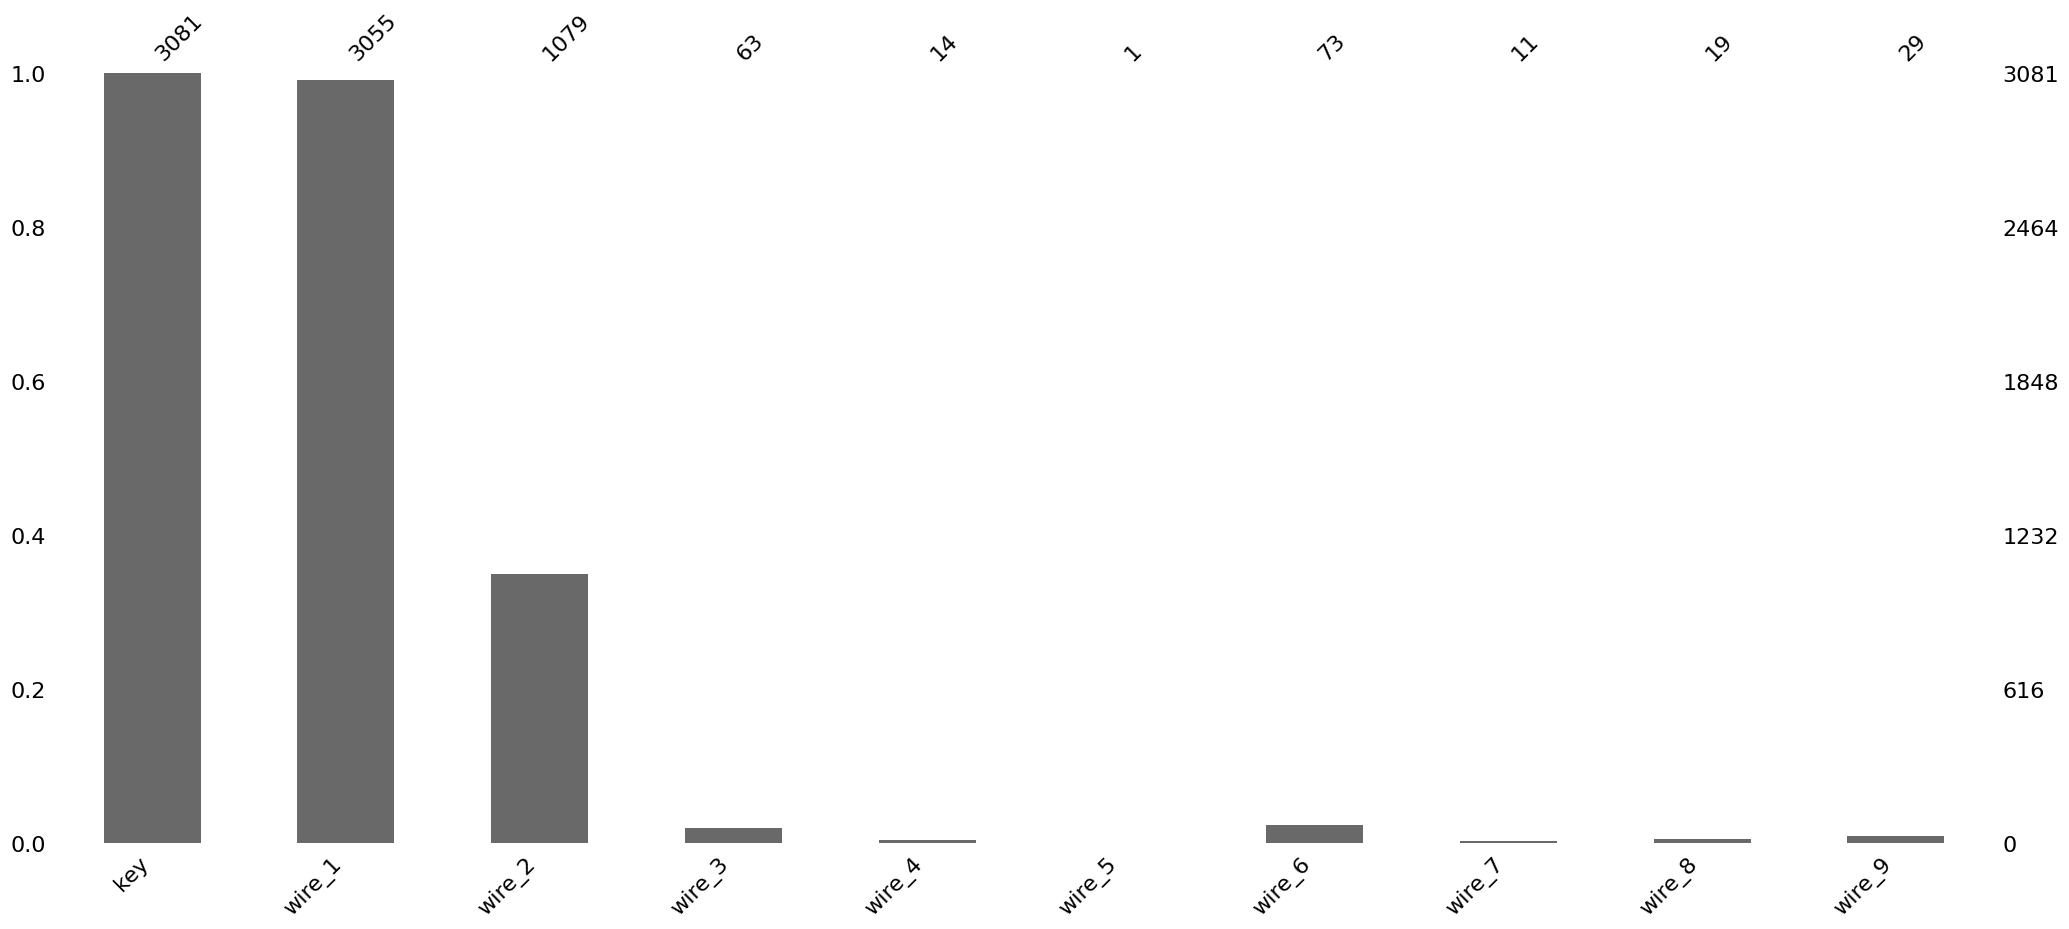

2026-03-03 22:10:08 [INFO] __main__: Характеристики базы данных


,count,mean,std,min,25%,50%,75%,max
key,3081.0,1623.426485,932.996726,1.0,823.0,1619.0,2434.0,3241.0


In [62]:
df_wire_time = check_data(df_wire_time)

In [63]:
wire_time_cols = [col for col in df_wire_time.columns if 'wire_' in col.lower()]
df_wire_time[wire_time_cols] = df_wire_time[wire_time_cols].astype('datetime64[ns]')

In [64]:
df_wire_time.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   key     3081 non-null   int64         
 1   wire_1  3055 non-null   datetime64[ns]
 2   wire_2  1079 non-null   datetime64[ns]
 3   wire_3  63 non-null     datetime64[ns]
 4   wire_4  14 non-null     datetime64[ns]
 5   wire_5  1 non-null      datetime64[ns]
 6   wire_6  73 non-null     datetime64[ns]
 7   wire_7  11 non-null     datetime64[ns]
 8   wire_8  19 non-null     datetime64[ns]
 9   wire_9  29 non-null     datetime64[ns]
dtypes: datetime64[ns](9), int64(1)
memory usage: 240.8 KB


In [65]:
df_wire_time['начало_засыпок'] = df_wire_time[wire_time_cols].min(axis=1)
df_wire_time['конец_засыпок'] = df_wire_time[wire_time_cols].max(axis=1)
df_wire_time['общее_время_засыпок'] = (df_wire_time['конец_засыпок'] - df_wire_time['начало_засыпок']).dt.total_seconds()

In [66]:
# ну и средний интервал между подачами заодно

df_wire_time['интервал_подачи_avg'] = (
    df_wire_time[wire_time_cols]
    .apply(lambda row: row.dropna().sort_values().diff().dt.total_seconds().mean(), axis=1)
)

In [67]:
display(df_wire_time.head())
display(df_wire_time.info())
display(df_wire_time.describe().T)

,key,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9,начало_засыпок,конец_засыпок,общее_время_засыпок,интервал_подачи_avg
0,1,2019-05-03 11:06:19,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:06:19,2019-05-03 11:06:19,0.0,NaN
1,2,2019-05-03 11:36:50,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:36:50,2019-05-03 11:36:50,0.0,NaN
2,3,2019-05-03 12:11:46,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 12:11:46,2019-05-03 12:11:46,0.0,NaN
3,4,2019-05-03 12:43:22,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 12:43:22,2019-05-03 12:43:22,0.0,NaN
4,5,2019-05-03 13:20:44,2019-05-03 13:15:34,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 13:15:34,2019-05-03 13:20:44,310.0,310.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   key                  3081 non-null   int64         
 1   wire_1               3055 non-null   datetime64[ns]
 2   wire_2               1079 non-null   datetime64[ns]
 3   wire_3               63 non-null     datetime64[ns]
 4   wire_4               14 non-null     datetime64[ns]
 5   wire_5               1 non-null      datetime64[ns]
 6   wire_6               73 non-null     datetime64[ns]
 7   wire_7               11 non-null     datetime64[ns]
 8   wire_8               19 non-null     datetime64[ns]
 9   wire_9               29 non-null     datetime64[ns]
 10  начало_засыпок       3081 non-null   datetime64[ns]
 11  конец_засыпок        3081 non-null   datetime64[ns]
 12  общее_время_засыпок  3081 non-null   float64       
 13  интервал_подачи_avg  1145 non-nul

None

,count,mean,min,25%,50%,75%,max,std
key,3081.0,1623.426485,1.0,823.0,1619.0,2434.0,3241.0,932.996726
wire_1,3055,2019-07-05 23:22:34.279541760,2019-05-03 11:06:19,2019-06-04 19:30:11.500000,2019-07-03 06:36:23,2019-08-08 08:56:06.500000,2019-09-06 17:10:06,NaN
wire_2,1079,2019-07-07 01:07:08.735866624,2019-05-03 13:15:34,2019-06-05 14:50:26.500000,2019-07-04 23:13:39,2019-08-08 23:15:17,2019-09-06 07:35:40,NaN
wire_3,63,2019-07-10 15:09:58.650793472,2019-05-04 04:34:27,2019-06-11 14:17:38.500000,2019-07-21 10:04:47,2019-08-12 22:54:46,2019-09-02 07:14:44,NaN
wire_4,14,2019-07-11 13:44:37,2019-05-07 15:19:17,2019-07-20 17:58:53.750000128,2019-07-27 05:45:26.500000,2019-07-27 16:20:04.750000128,2019-08-13 03:16:45,NaN
wire_5,1,2019-08-13 06:14:30,2019-08-13 06:14:30,2019-08-13 06:14:30,2019-08-13 06:14:30,2019-08-13 06:14:30,2019-08-13 06:14:30,NaN
wire_6,73,2019-07-07 11:51:15.095890432,2019-05-07 14:46:05,2019-05-08 21:47:30,2019-07-28 05:00:32,2019-08-13 13:33:02,2019-08-18 19:10:56,NaN
wire_7,11,2019-08-07 01:16:08.090909184,2019-07-27 05:49:05,2019-07-27 16:27:27,2019-08-12 21:48:11,2019-08-13 02:02:55.500000,2019-08-13 10:25:22,NaN
wire_8,19,2019-06-23 07:47:49.052631552,2019-05-14 11:29:24,2019-05-14 14:20:07.500000,2019-05-14 16:55:09,2019-08-16 05:06:53.500000,2019-08-16 08:56:23,NaN
wire_9,29,2019-07-01 11:56:04.793103616,2019-05-04 17:21:27,2019-06-09 19:36:17,2019-06-11 10:10:21,2019-08-09 06:49:04,2019-09-03 12:55:23,NaN


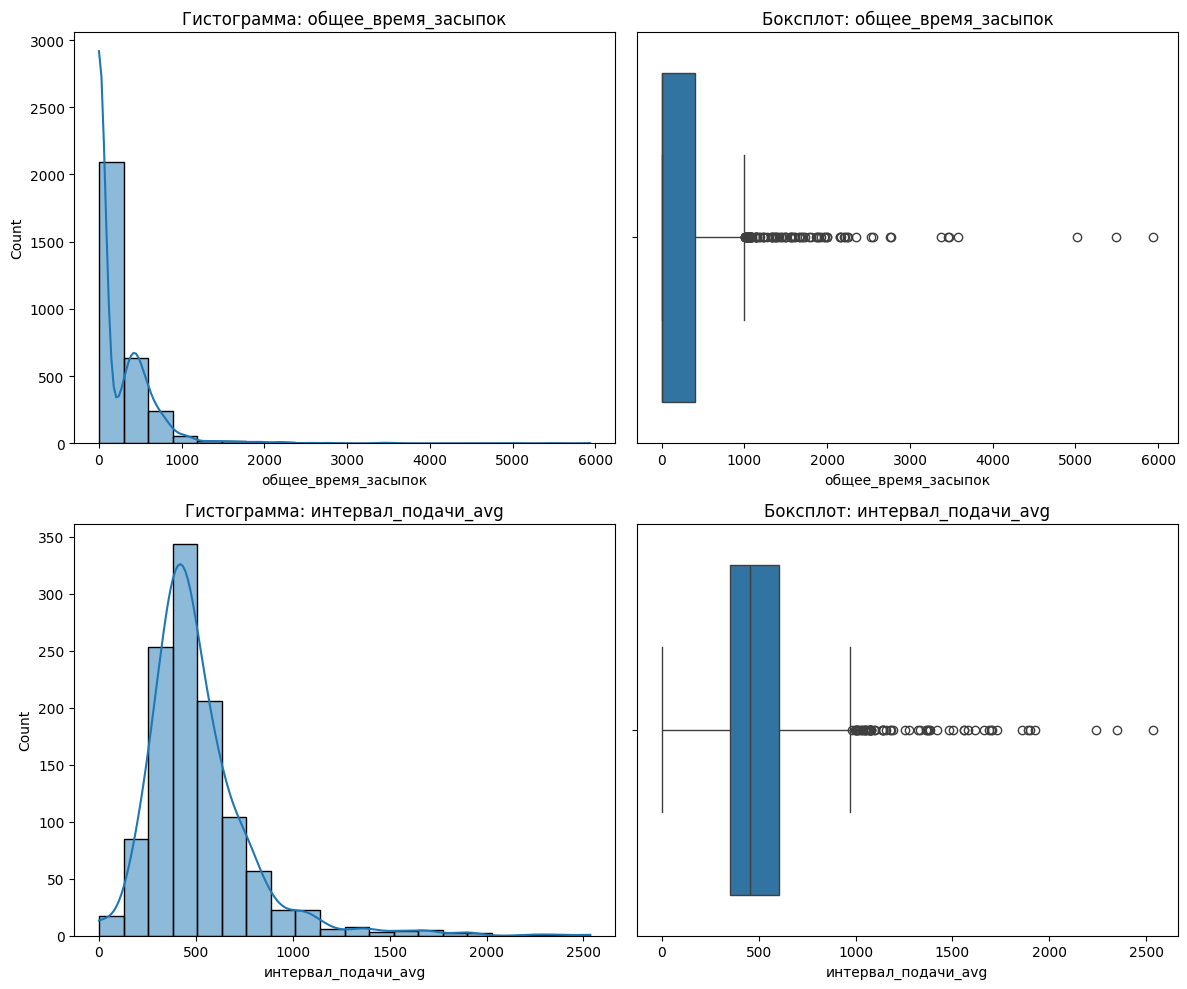

In [68]:
# и посмотрим что вышло
cols = ['общее_время_засыпок', 'интервал_подачи_avg']
plot_combined(df_wire_time, col=cols, target=None, col_type=None, legend_loc='best')

Где-то большие промежутки и общее время плавки добавок, но штош поделать...

##### Выводы

Все данные были изучены и проанализированы  
Обработаны пропуски  
Скорректированы типы данных  
Реализованы новые признаки  

#### Объединение данных

##### Объединение

In [69]:
df_merged = pd.merge(df_arc, df_bulk, on='key', how='outer')
df_merged = pd.merge(df_merged, df_bulk_time, on='key', how='outer', suffixes=('', '_bulk_time'))
df_merged = pd.merge(df_merged, df_gas, on='key', how='outer')
df_merged = pd.merge(df_merged, df_temp, on='key', how='outer')
df_merged = pd.merge(df_merged, df_wire, on='key', how='outer')
df_merged = pd.merge(df_merged, df_wire_time, on='key', how='outer', suffixes=('', '_wire_time'))

In [70]:
display(df_merged.drop_duplicates())

,key,начало_нагрева_дугой_1,начало_нагрева_дугой_2,начало_нагрева_дугой_3,начало_нагрева_дугой_4,начало_нагрева_дугой_5,начало_нагрева_дугой_6,начало_нагрева_дугой_7,начало_нагрева_дугой_8,начало_нагрева_дугой_9,...,wire_4_wire_time,wire_5_wire_time,wire_6_wire_time,wire_7_wire_time,wire_8_wire_time,wire_9_wire_time,начало_засыпок_wire_time,конец_засыпок_wire_time,общее_время_засыпок_wire_time,интервал_подачи_avg_wire_time
0,1,2019-05-03 11:02:14,2019-05-03 11:07:28,2019-05-03 11:11:44,2019-05-03 11:18:14,2019-05-03 11:26:09,NaT,NaT,NaT,NaT,...,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:06:19,2019-05-03 11:06:19,0.0,NaN
1,2,2019-05-03 11:34:14,2019-05-03 11:38:50,2019-05-03 11:46:19,2019-05-03 11:49:48,NaT,NaT,NaT,NaT,NaT,...,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 11:36:50,2019-05-03 11:36:50,0.0,NaN
2,3,2019-05-03 12:06:54,2019-05-03 12:13:52,2019-05-03 12:18:56,2019-05-03 12:25:43,2019-05-03 12:31:14,NaT,NaT,NaT,NaT,...,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 12:11:46,2019-05-03 12:11:46,0.0,NaN
3,4,2019-05-03 12:39:37,2019-05-03 12:44:47,2019-05-03 12:48:14,2019-05-03 12:53:12,NaT,NaT,NaT,NaT,NaT,...,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 12:43:22,2019-05-03 12:43:22,0.0,NaN
4,5,2019-05-03 13:11:13,2019-05-03 13:18:21,2019-05-03 13:23:32,2019-05-03 13:32:44,NaT,NaT,NaT,NaT,NaT,...,NaT,NaT,NaT,NaT,NaT,NaT,2019-05-03 13:15:34,2019-05-03 13:20:44,310.0,310.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3236,3237,2019-09-06 11:31:25,2019-09-06 11:35:48,2019-09-06 11:41:17,2019-09-06 11:46:32,2019-09-06 11:51:39,NaT,NaT,NaT,NaT,...,NaT,NaT,NaT,NaT,NaT,NaT,2019-09-06 11:33:38,2019-09-06 11:33:38,0.0,NaN
3237,3238,2019-09-06 12:16:25,2019-09-06 12:22:10,2019-09-06 12:28:45,NaT,NaT,NaT,NaT,NaT,NaT,...,NaT,NaT,NaT,NaT,NaT,NaT,2019-09-06 12:18:35,2019-09-06 12:18:35,0.0,NaN
3238,3239,2019-09-06 14:17:00,2019-09-06 14:22:59,2019-09-06 14:29:04,2019-09-06 14:33:44,2019-09-06 14:42:58,2019-09-06 14:57:08,2019-09-06 14:59:35,2019-09-06 15:03:45,NaT,...,NaT,NaT,NaT,NaT,NaT,NaT,2019-09-06 14:36:11,2019-09-06 14:36:11,0.0,NaN
3239,3240,2019-09-06 15:25:31,2019-09-06 15:31:02,2019-09-06 15:58:45,2019-09-06 16:02:41,2019-09-06 16:21:54,NaT,NaT,NaT,NaT,...,NaT,NaT,NaT,NaT,NaT,NaT,2019-09-06 15:33:55,2019-09-06 15:33:55,0.0,NaN


Надо бы удалить временные столбцы... они нам не понадобятся

In [71]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3241 entries, 0 to 3240
Columns: 131 entries, key to интервал_подачи_avg_wire_time
dtypes: datetime64[ns](62), float64(68), int64(1)
memory usage: 3.2 MB


In [72]:
non_datetime_cols = df_merged.select_dtypes(exclude=['datetime64[ns]']).columns
main_df = df_merged[non_datetime_cols].copy()

In [73]:
main_df.head()

,key,активная_мощность_1,активная_мощность_2,активная_мощность_3,активная_мощность_4,активная_мощность_5,активная_мощность_6,активная_мощность_7,активная_мощность_8,активная_мощность_9,...,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9,общее_время_засыпок_wire_time,интервал_подачи_avg_wire_time
0,1,0.305130,0.765658,0.580313,0.518496,0.867133,0.0,0.0,0.0,0.0,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,2,0.381124,0.261665,0.710297,0.786322,0.000000,0.0,0.0,0.0,0.0,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
2,3,1.101678,0.542675,0.774632,1.222963,0.421693,0.0,0.0,0.0,0.0,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,4,0.642946,0.310693,0.887855,0.864995,0.000000,0.0,0.0,0.0,0.0,...,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,5,0.324563,0.573810,0.461620,0.892957,0.000000,0.0,0.0,0.0,0.0,...,9.11456,0.0,0.0,0.0,0.0,0.0,0.0,0.0,310.0,310.0


In [74]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3241 entries, 0 to 3240
Data columns (total 69 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   key                            3241 non-null   int64  
 1   активная_мощность_1            3214 non-null   float64
 2   активная_мощность_2            3214 non-null   float64
 3   активная_мощность_3            3214 non-null   float64
 4   активная_мощность_4            3214 non-null   float64
 5   активная_мощность_5            3214 non-null   float64
 6   активная_мощность_6            3214 non-null   float64
 7   активная_мощность_7            3214 non-null   float64
 8   активная_мощность_8            3214 non-null   float64
 9   активная_мощность_9            3214 non-null   float64
 10  активная_мощность_10           3214 non-null   float64
 11  активная_мощность_11           3214 non-null   float64
 12  активная_мощность_12           3214 non-null   f

##### Исследуем итоговую таблицу

interval columns not set, guessing: ['активная_мощность_1', 'активная_мощность_2', 'активная_мощность_3', 'активная_мощность_4', 'активная_мощность_5', 'активная_мощность_6', 'активная_мощность_7', 'активная_мощность_8', 'активная_мощность_9', 'активная_мощность_10', 'активная_мощность_11', 'активная_мощность_12', 'активная_мощность_13', 'активная_мощность_14', 'активная_мощность_15', 'активная_мощность_16', 'реактивная_мощность_1', 'реактивная_мощность_2', 'реактивная_мощность_3', 'реактивная_мощность_4', 'реактивная_мощность_5', 'реактивная_мощность_6', 'реактивная_мощность_7', 'реактивная_мощность_8', 'реактивная_мощность_9', 'реактивная_мощность_10', 'реактивная_мощность_11', 'реактивная_мощность_12', 'реактивная_мощность_13', 'реактивная_мощность_14', 'реактивная_мощность_15', 'реактивная_мощность_16', 'средняя_активная_мощность', 'средняя_реактивная_мощность', 'среднее_время_нагрева_сек', 'bulk_1', 'bulk_2', 'bulk_3', 'bulk_4', 'bulk_5', 'bulk_6', 'bulk_7', 'bulk_8', 'bulk_9', 'b

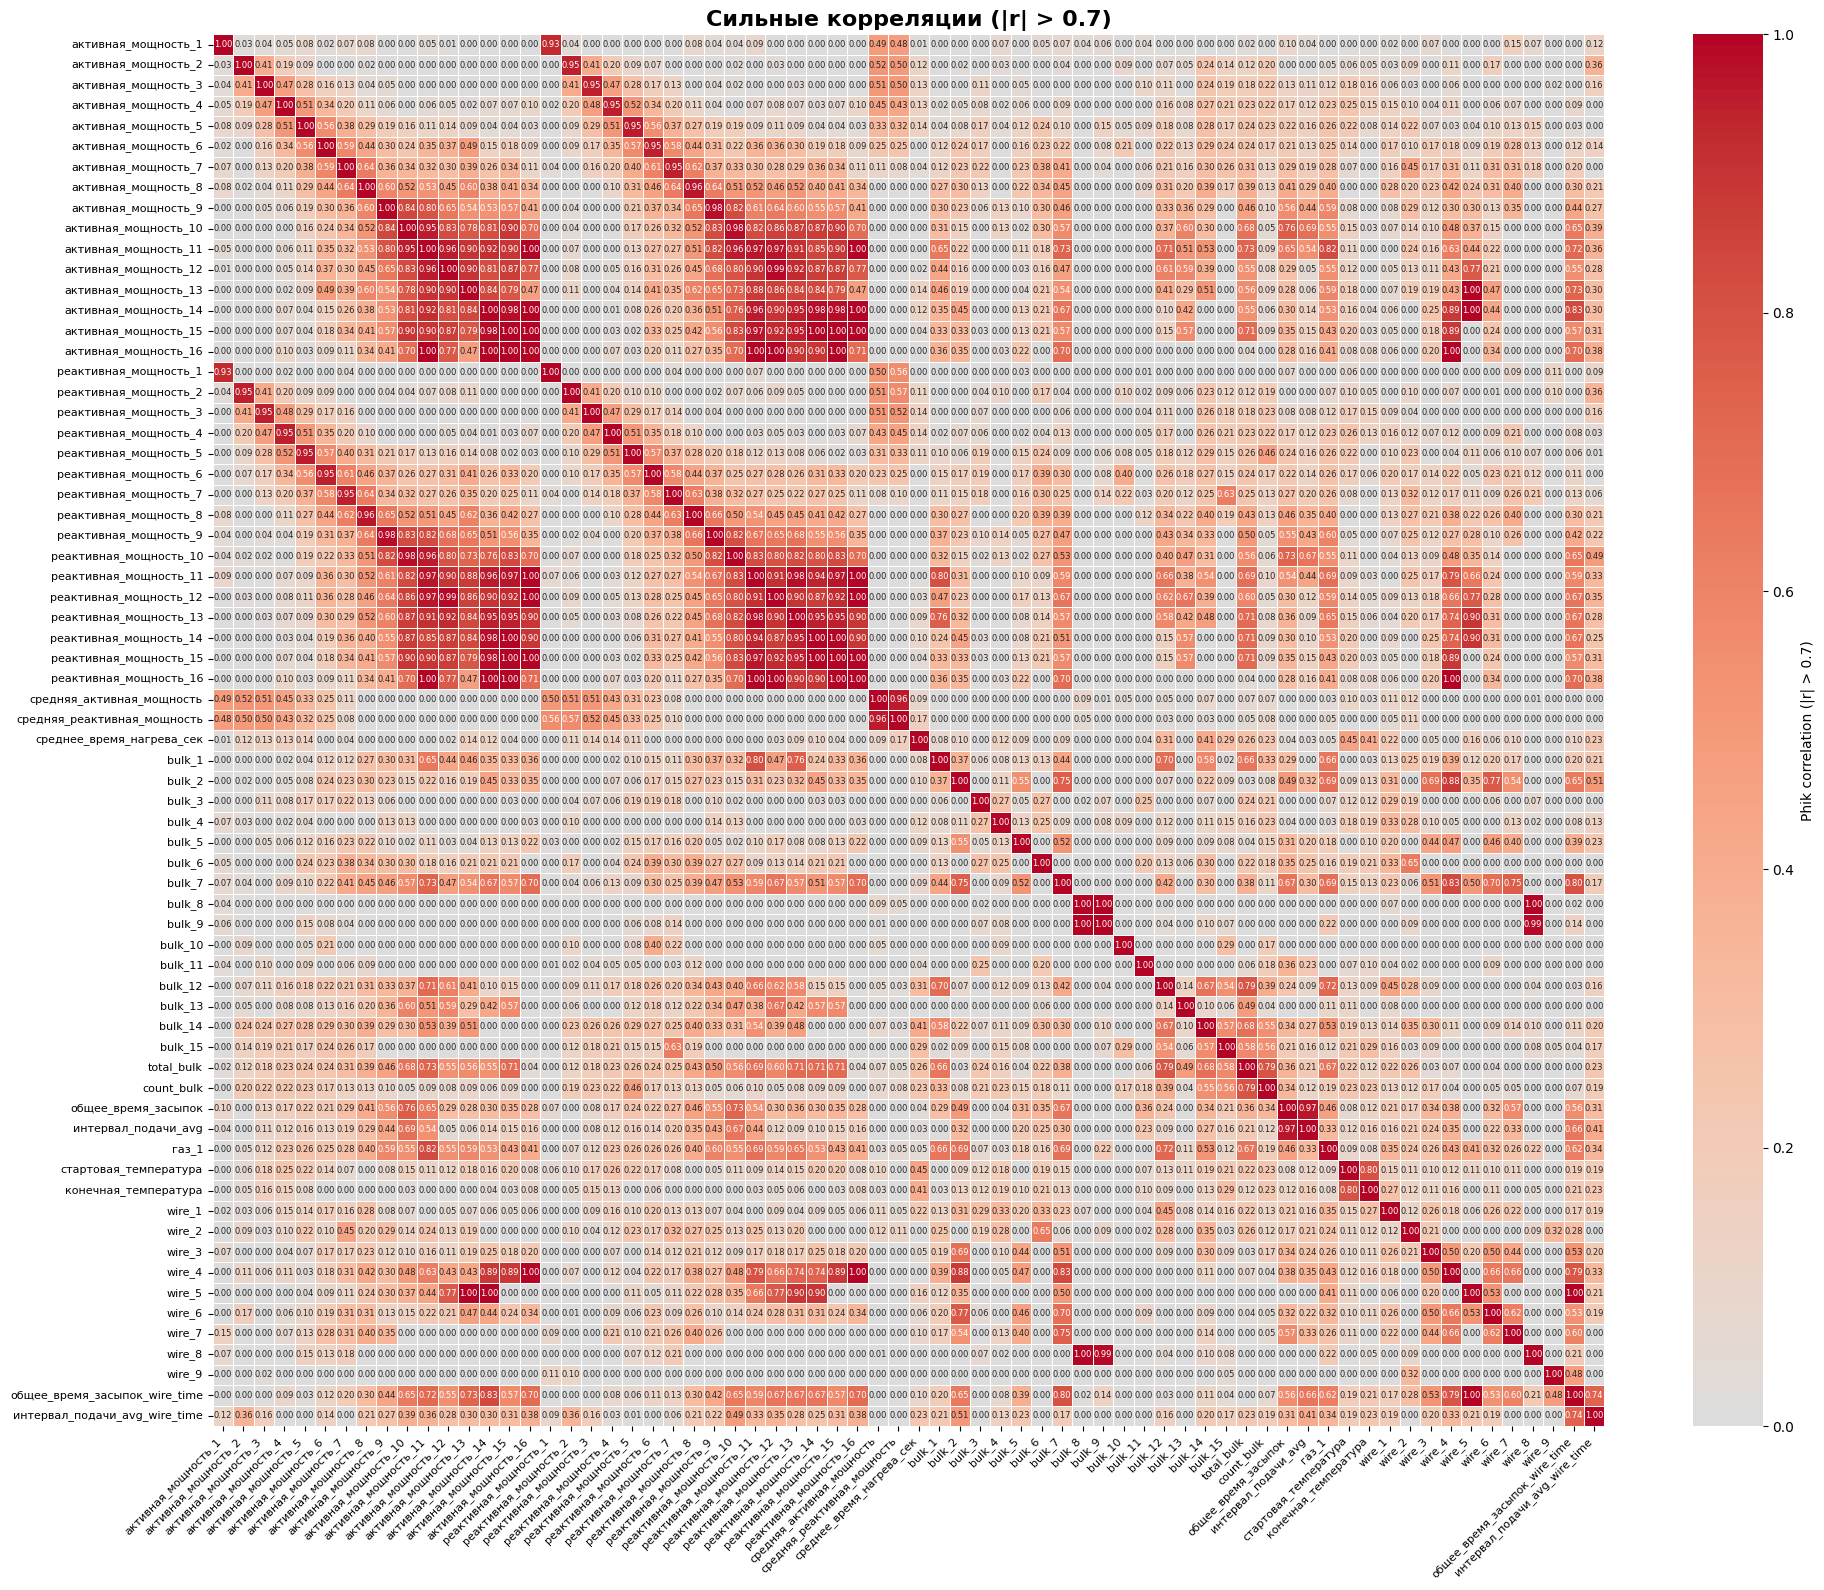

In [75]:
df_cor = main_df.drop(columns=['key'])
correlation_matrix = df_cor.phik_matrix()

plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            center=0,
            square=True, 
            linewidths=0.5,
            cbar_kws={'label': 'Phik correlation (|r| > 0.7)'},
            annot_kws={'size': 6})
plt.title('Сильные корреляции (|r| > 0.7)', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# ЗЫ: знаю, что лучше писать руками признаки, но мне так нравится больше + я проверяю, чтобы все было нормально

In [76]:
# выведем корреляцию с таргетом
corr = correlation_matrix[TARGET].sort_values(ascending=False)

logger.info(f"Сильня корреляция с {TARGET}:")
display(corr[corr >= 0.7])

logger.info(f"Слабая корреляция с {TARGET}:")
display(corr[corr < 0.7])

2026-03-03 22:10:20 [INFO] __main__: Сильня корреляция с конечная_температура:


конечная_температура     1.000000
стартовая_температура    0.803975
Name: конечная_температура, dtype: float64

2026-03-03 22:10:20 [INFO] __main__: Слабая корреляция с конечная_температура:


среднее_время_нагрева_сек        0.405370
bulk_15                          0.291605
wire_1                           0.268824
интервал_подачи_avg_wire_time    0.228962
count_bulk                       0.225518
                                   ...   
bulk_9                           0.000000
bulk_10                          0.000000
wire_5                           0.000000
wire_7                           0.000000
wire_9                           0.000000
Name: конечная_температура, Length: 66, dtype: float64

In [77]:
# проверим зависимость VIF
VIF = main_df.drop(columns=['key', TARGET])

VIF = pd.get_dummies(VIF, drop_first=True)
VIF = VIF.assign(const=1)

for col in VIF.select_dtypes(include='bool').columns:
    VIF[col] = VIF[col].astype(int)

VIF = VIF.dropna()

# Пересчитываем VIF
vif_data = pd.DataFrame()
vif_data["Признаки"] = VIF.columns
vif_data["VIF"] = [variance_inflation_factor(VIF.values, i) for i in range(VIF.shape[1])]

# Удаляем константу из результатов
vif_data = vif_data[vif_data["Признаки"] != "const"]
display(vif_data)

,Признаки,VIF
0,активная_мощность_1,57.584039
1,активная_мощность_2,59.767459
2,активная_мощность_3,60.786595
3,активная_мощность_4,91.080780
4,активная_мощность_5,113.444224
...,...,...
62,wire_7,2.196815
63,wire_8,71.686207
64,wire_9,1.177738
65,общее_время_засыпок_wire_time,9.822343


По VIF всё больно - и как хорошо, что у нас нет линеек, а для всего остальное VIF чистить нет смысла  
Тогда просто делим данные и переходим к обучению

In [78]:
# зафиналиваем пропуски нулями
main_df = main_df.fillna(0)

## Подготовим данные для обучения

In [79]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3241 entries, 0 to 3240
Data columns (total 69 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   key                            3241 non-null   int64  
 1   активная_мощность_1            3241 non-null   float64
 2   активная_мощность_2            3241 non-null   float64
 3   активная_мощность_3            3241 non-null   float64
 4   активная_мощность_4            3241 non-null   float64
 5   активная_мощность_5            3241 non-null   float64
 6   активная_мощность_6            3241 non-null   float64
 7   активная_мощность_7            3241 non-null   float64
 8   активная_мощность_8            3241 non-null   float64
 9   активная_мощность_9            3241 non-null   float64
 10  активная_мощность_10           3241 non-null   float64
 11  активная_мощность_11           3241 non-null   float64
 12  активная_мощность_12           3241 non-null   f

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    main_df.drop([TARGET], axis=1),
    main_df[TARGET],
    test_size = TEST_SIZE, 
    random_state = RANDOM_STATE)

In [81]:
X_train.shape, X_test.shape

((2430, 68), (811, 68))